# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [5]:

#cargamos los datos como arreglos numpy
features= np.loadtxt("RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("RRLyrae_labels_small.txt", delimiter=',')


In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [7]:
df["RR_Lyrae"].value_counts()

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64

In [8]:
2000/(2000+483)

0.8054772452678212

### Preguntas
1. ¿Este es un problema de clasificación o regresión?
2. ¿Es un problema binario o multiclase?
3. ¿Qué representa la variable objetivo?
4. ¿Las clases están balanceadas o desbalanceadas?
5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?

1. Es es un problema de clasificacion ya que se usar el color para poder predecir si es que es RR Lyrae o no.
2. Es un problema binario ya que los posibles resultados son o 1 o 0. ( si o no)
3. La variable objetivo representa la etiqueta o clase que el modelo debe aprender a predecir. Es el valor 1 si el objeto observado es una estrella RR Lyrae y el valor 0 si no lo es.
4. La mnuestra esta desbalanceada ya que 2000 estrelleas son no RR Lyrae y 483 si lo son.
5. Si hay muchas mas estrellas no RR Lyrae, el modelo va a tender a predecir lo mismo. Solo el 20% de las estrellas es RR Lyrae, entonces al predecir muchas como no Lyrae, nos va a dar un accuracy alto, pero no necesariamente porque se predijo bien.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

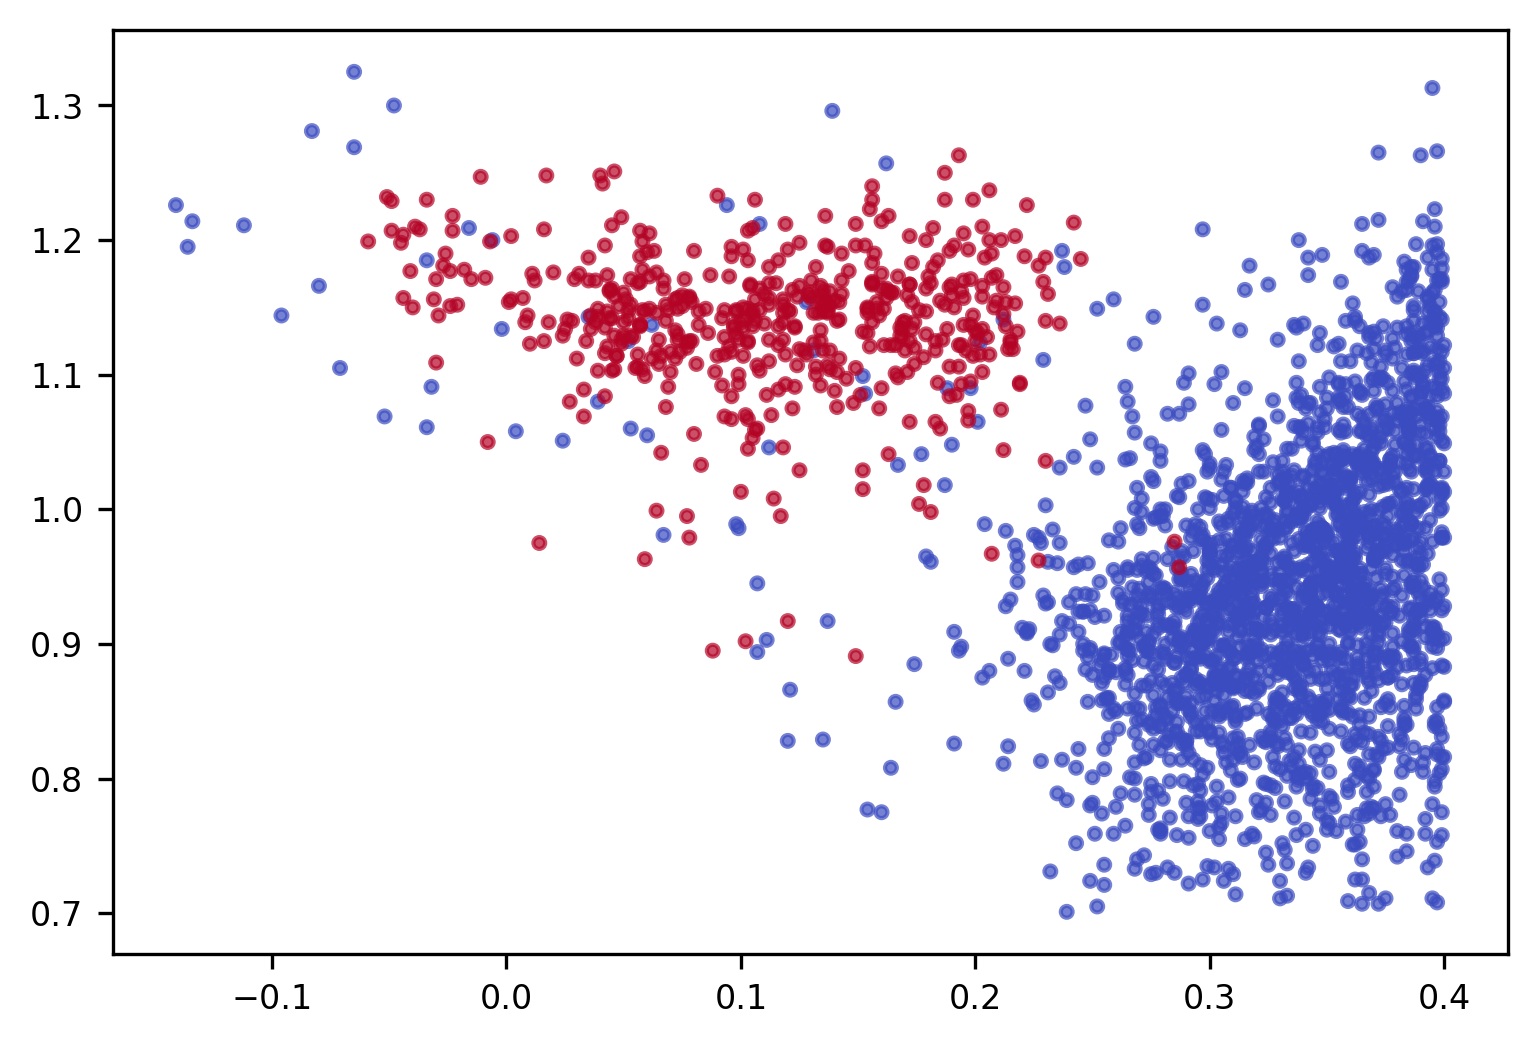

In [9]:
#complete la celda
plt.figure(figsize=(6,4))

sc=plt.scatter(df['u-g'], df['g-r'], c=df['RR_Lyrae'], cmap='coolwarm', s=8, alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?
2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?

Se puede ver una separacion entre las RR Lyra y las no RR Lyrae segun su color. En la region superior mas hacia la izquierda hay mas estrellas RR Lyrae.

Pareciera que si se puede usar un arbol de desición ya que se pueden separar por regiones tomando cnodiciones de mayor o menor.

#### Separe los datos en entrenamiento y prueba

In [10]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [11]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [12]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?
2. ¿Por qué eso podría afectar la evaluación del modelo?
3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?

1. Si hacemos una particion aleatoria e posible que tomemos casi puras estrellas que no son RR Lyrae para el entrenamitno, lo que haria que el modelo creo que todas son no RR Lyrae.
2. Si solo enrtena con estrllas no RR Lyra no tiene como saber de las que si son. Lo que lleva a una prediccion erronea o tiende a subestimar las RR Lyrae.
3. tomar una muestra aleatoria para el entreaniento dentro de las RR Lyrae y ortra dentro de las no RR Lyrae. Luego se mezclan entre llegas teniendo asi un set de entrenamiento balanceado que no sobreestima y no subestima.


#### Ahora entrenaremos un árbol de decisión (modelo base)

In [13]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)


#### Visualicemos el árbol

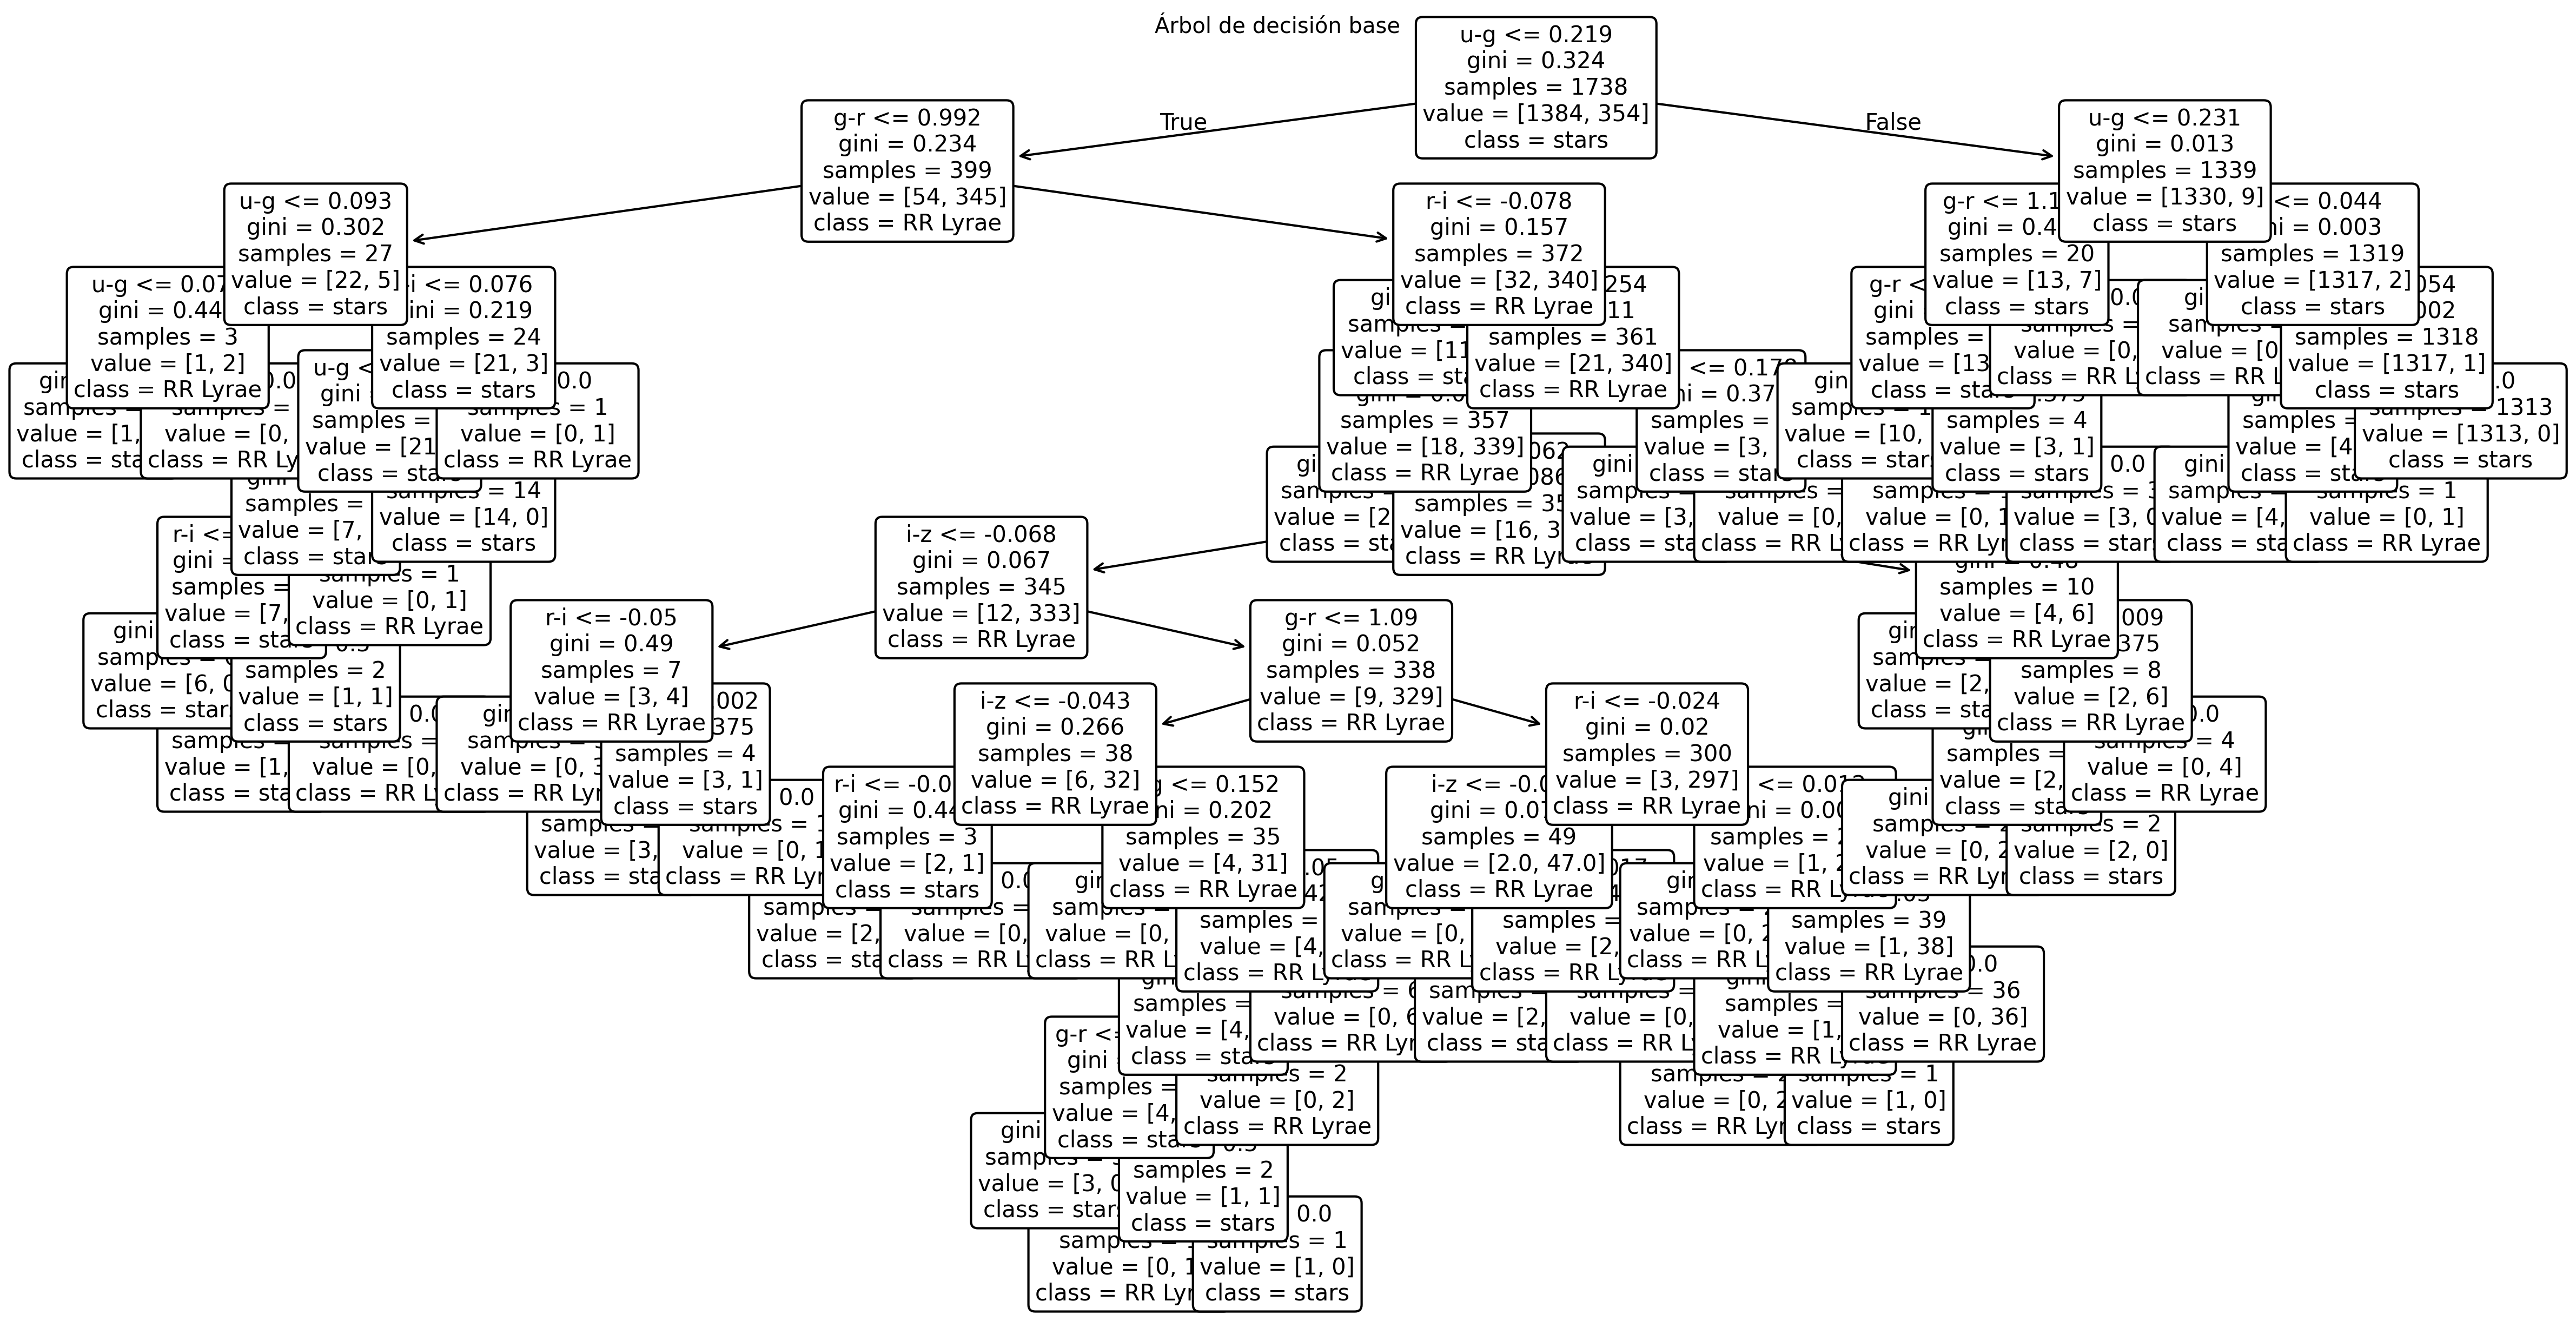

In [14]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

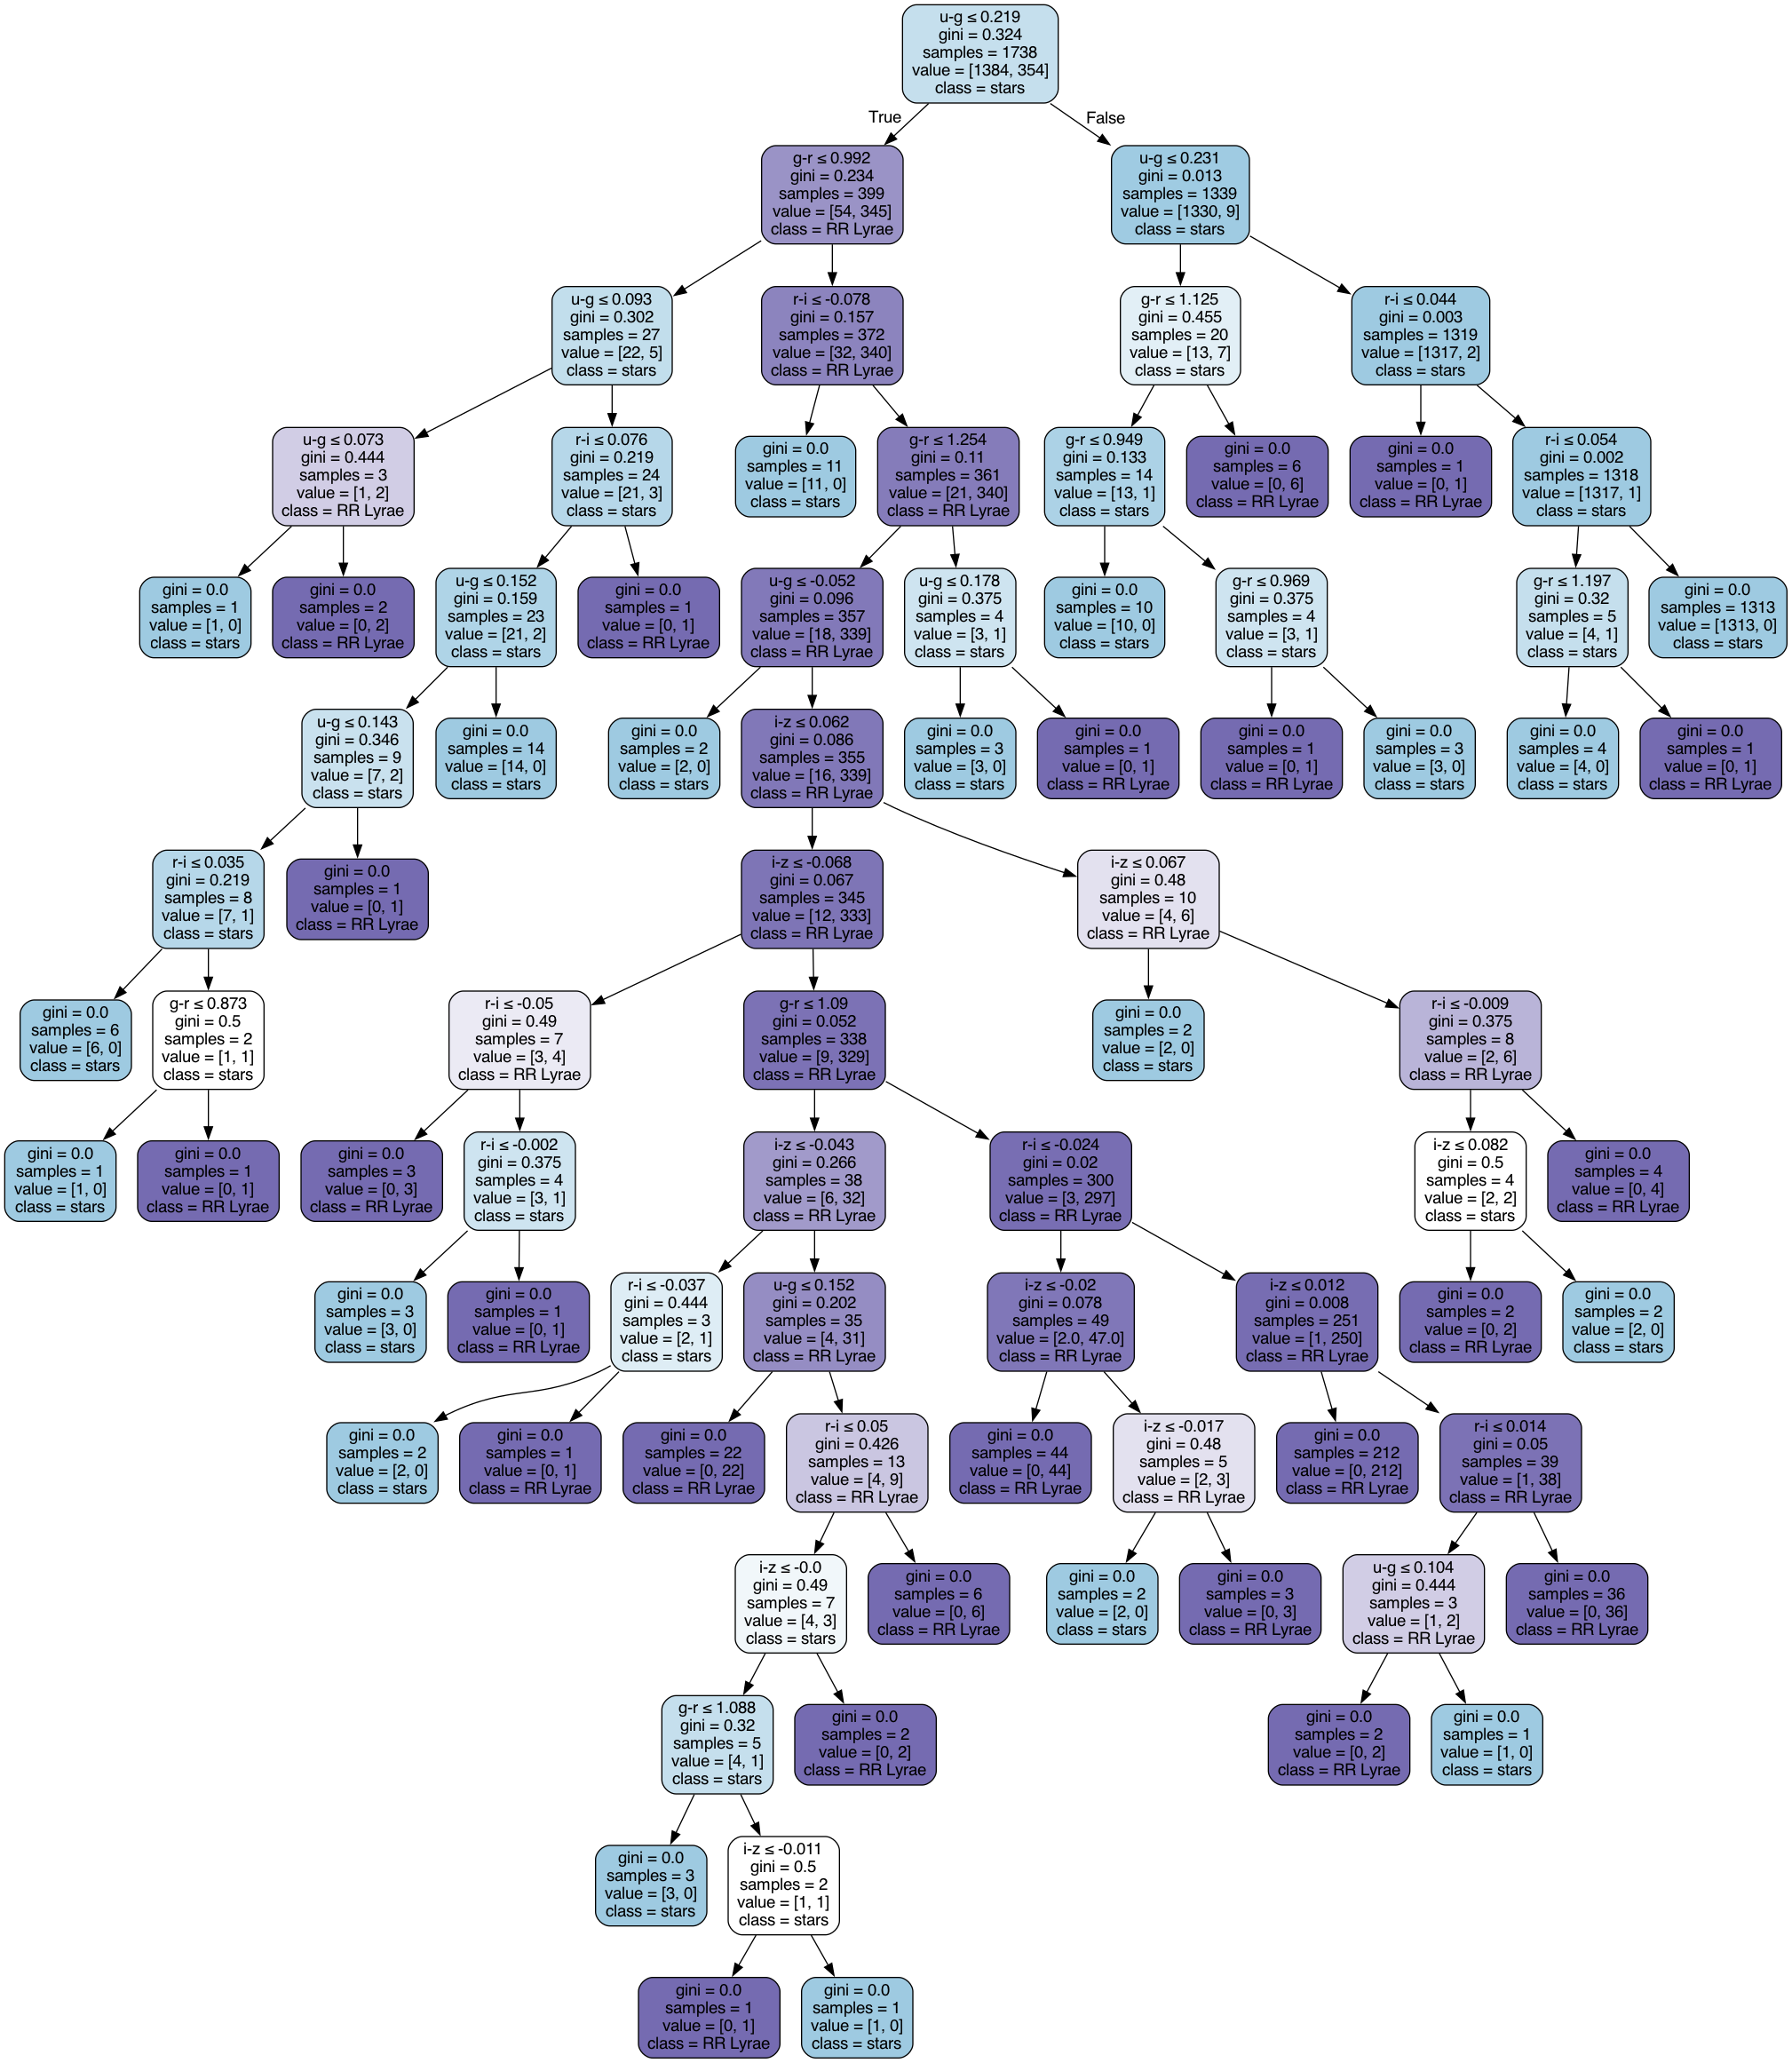

In [15]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.
2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?

1. El arbol parece ser muy complejo. Hay ramas que llegan hasta las 14 divisiones.
2. Si es demasiado profundo, el arbol puede empezar a aprender de memoria el patron y hacer "overfitting".

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [16]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [17]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

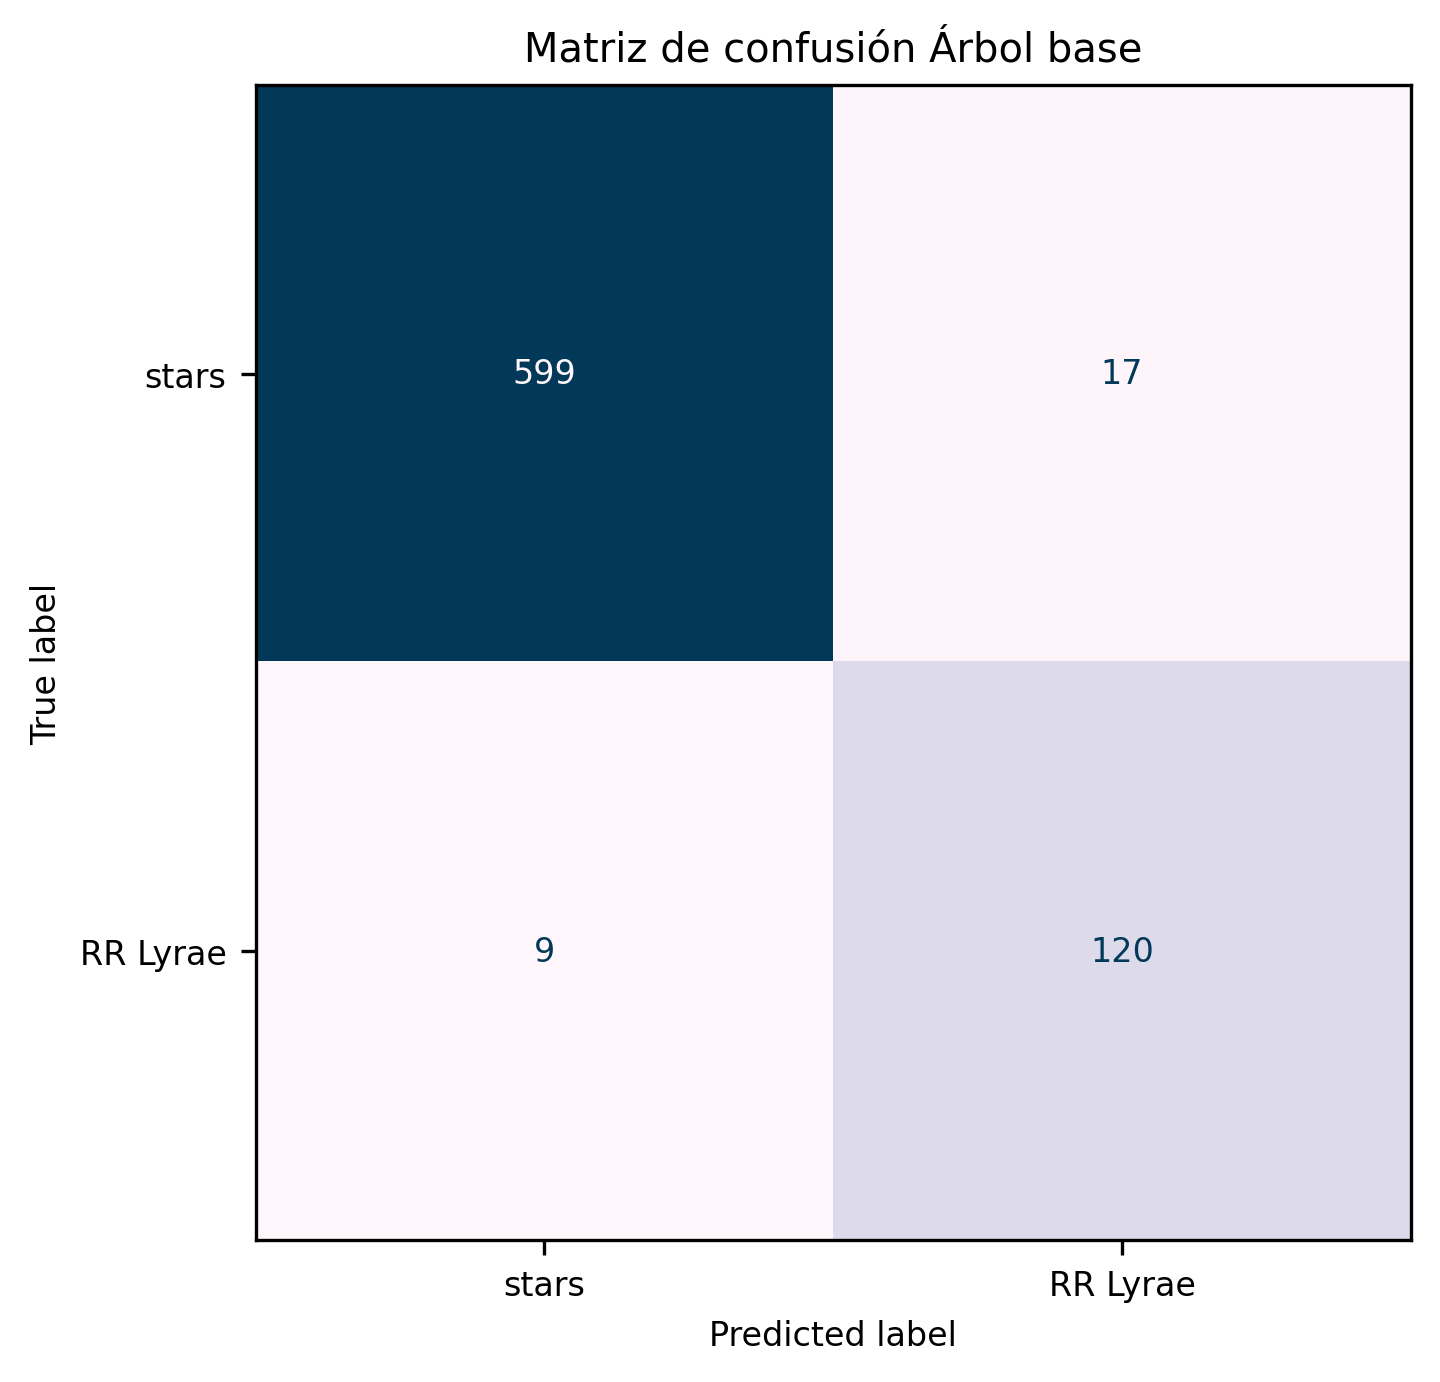

In [19]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



1. Leyendo la matriz se tiene: 
TP = 120, TN = 599, FP = 17 y FN = 9


In [22]:
TP = 120
TN = 599
FP = 17
FN = 9
Accuracy = (TP + TN)/(TP+TN+FP+FN)
Presision = TP/(TP+FP)
Recall = TP/(TP+FN)
F1_score = 2 * (Presision * Recall)/(Presision + Recall)

print("Se tiene un Accuracy de {}, una presición de {},\nun recall de {} y un F1 de {}" .format(Accuracy, Presision, Recall, F1_score))

Se tiene un Accuracy de 0.9651006711409396, una presición de 0.8759124087591241,
un recall de 0.9302325581395349 y un F1 de 0.9022556390977443


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?

1. Un falso positivo es cuando el modelo predijo que la estrella seria una RR Lyrae pero en verdad era otro tipo de estrella y un falso negativo es cuando predijo que no era, pero en verdad era RR Lyrae.

2. Si se busca la mayor cantidad posible de RR Lyrae, el mayor error son los falsos negativos. Ya que al buscar la mayor cantidad de estas estrellas, los falsos negativos subestiman esta cantidad.

3. Si se buscara una muestra mas limpia, el problema son los falsos positivos ya que estos contaminan nuestra muestra.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [23]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [24]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x1740a5190>

In [25]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [26]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [27]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [28]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [29]:
scores3

{'fit_time': array([0.00423694, 0.00203919, 0.00238466, 0.00258422, 0.00256681]),
 'score_time': array([0.00051689, 0.00052094, 0.00054002, 0.00060415, 0.00076914]),
 'test_score': array([0.97987928, 0.96177062, 0.96579477, 0.97379032, 0.95564516])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [30]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [31]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.964 0.011


In [32]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.967 0.009


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [34]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklea

In [35]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [36]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bastianparedes/ML/lib/python3.9/site-packages/sklea

In [37]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.911 1.000
0.928 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [38]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [39]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [40]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [41]:
np.sum(y_cv3-y_cv2)

10

In [42]:
np.sum(y_cv2)

485

In [43]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

52

In [44]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [45]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [46]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [47]:
model = DecisionTreeClassifier(random_state = 5)

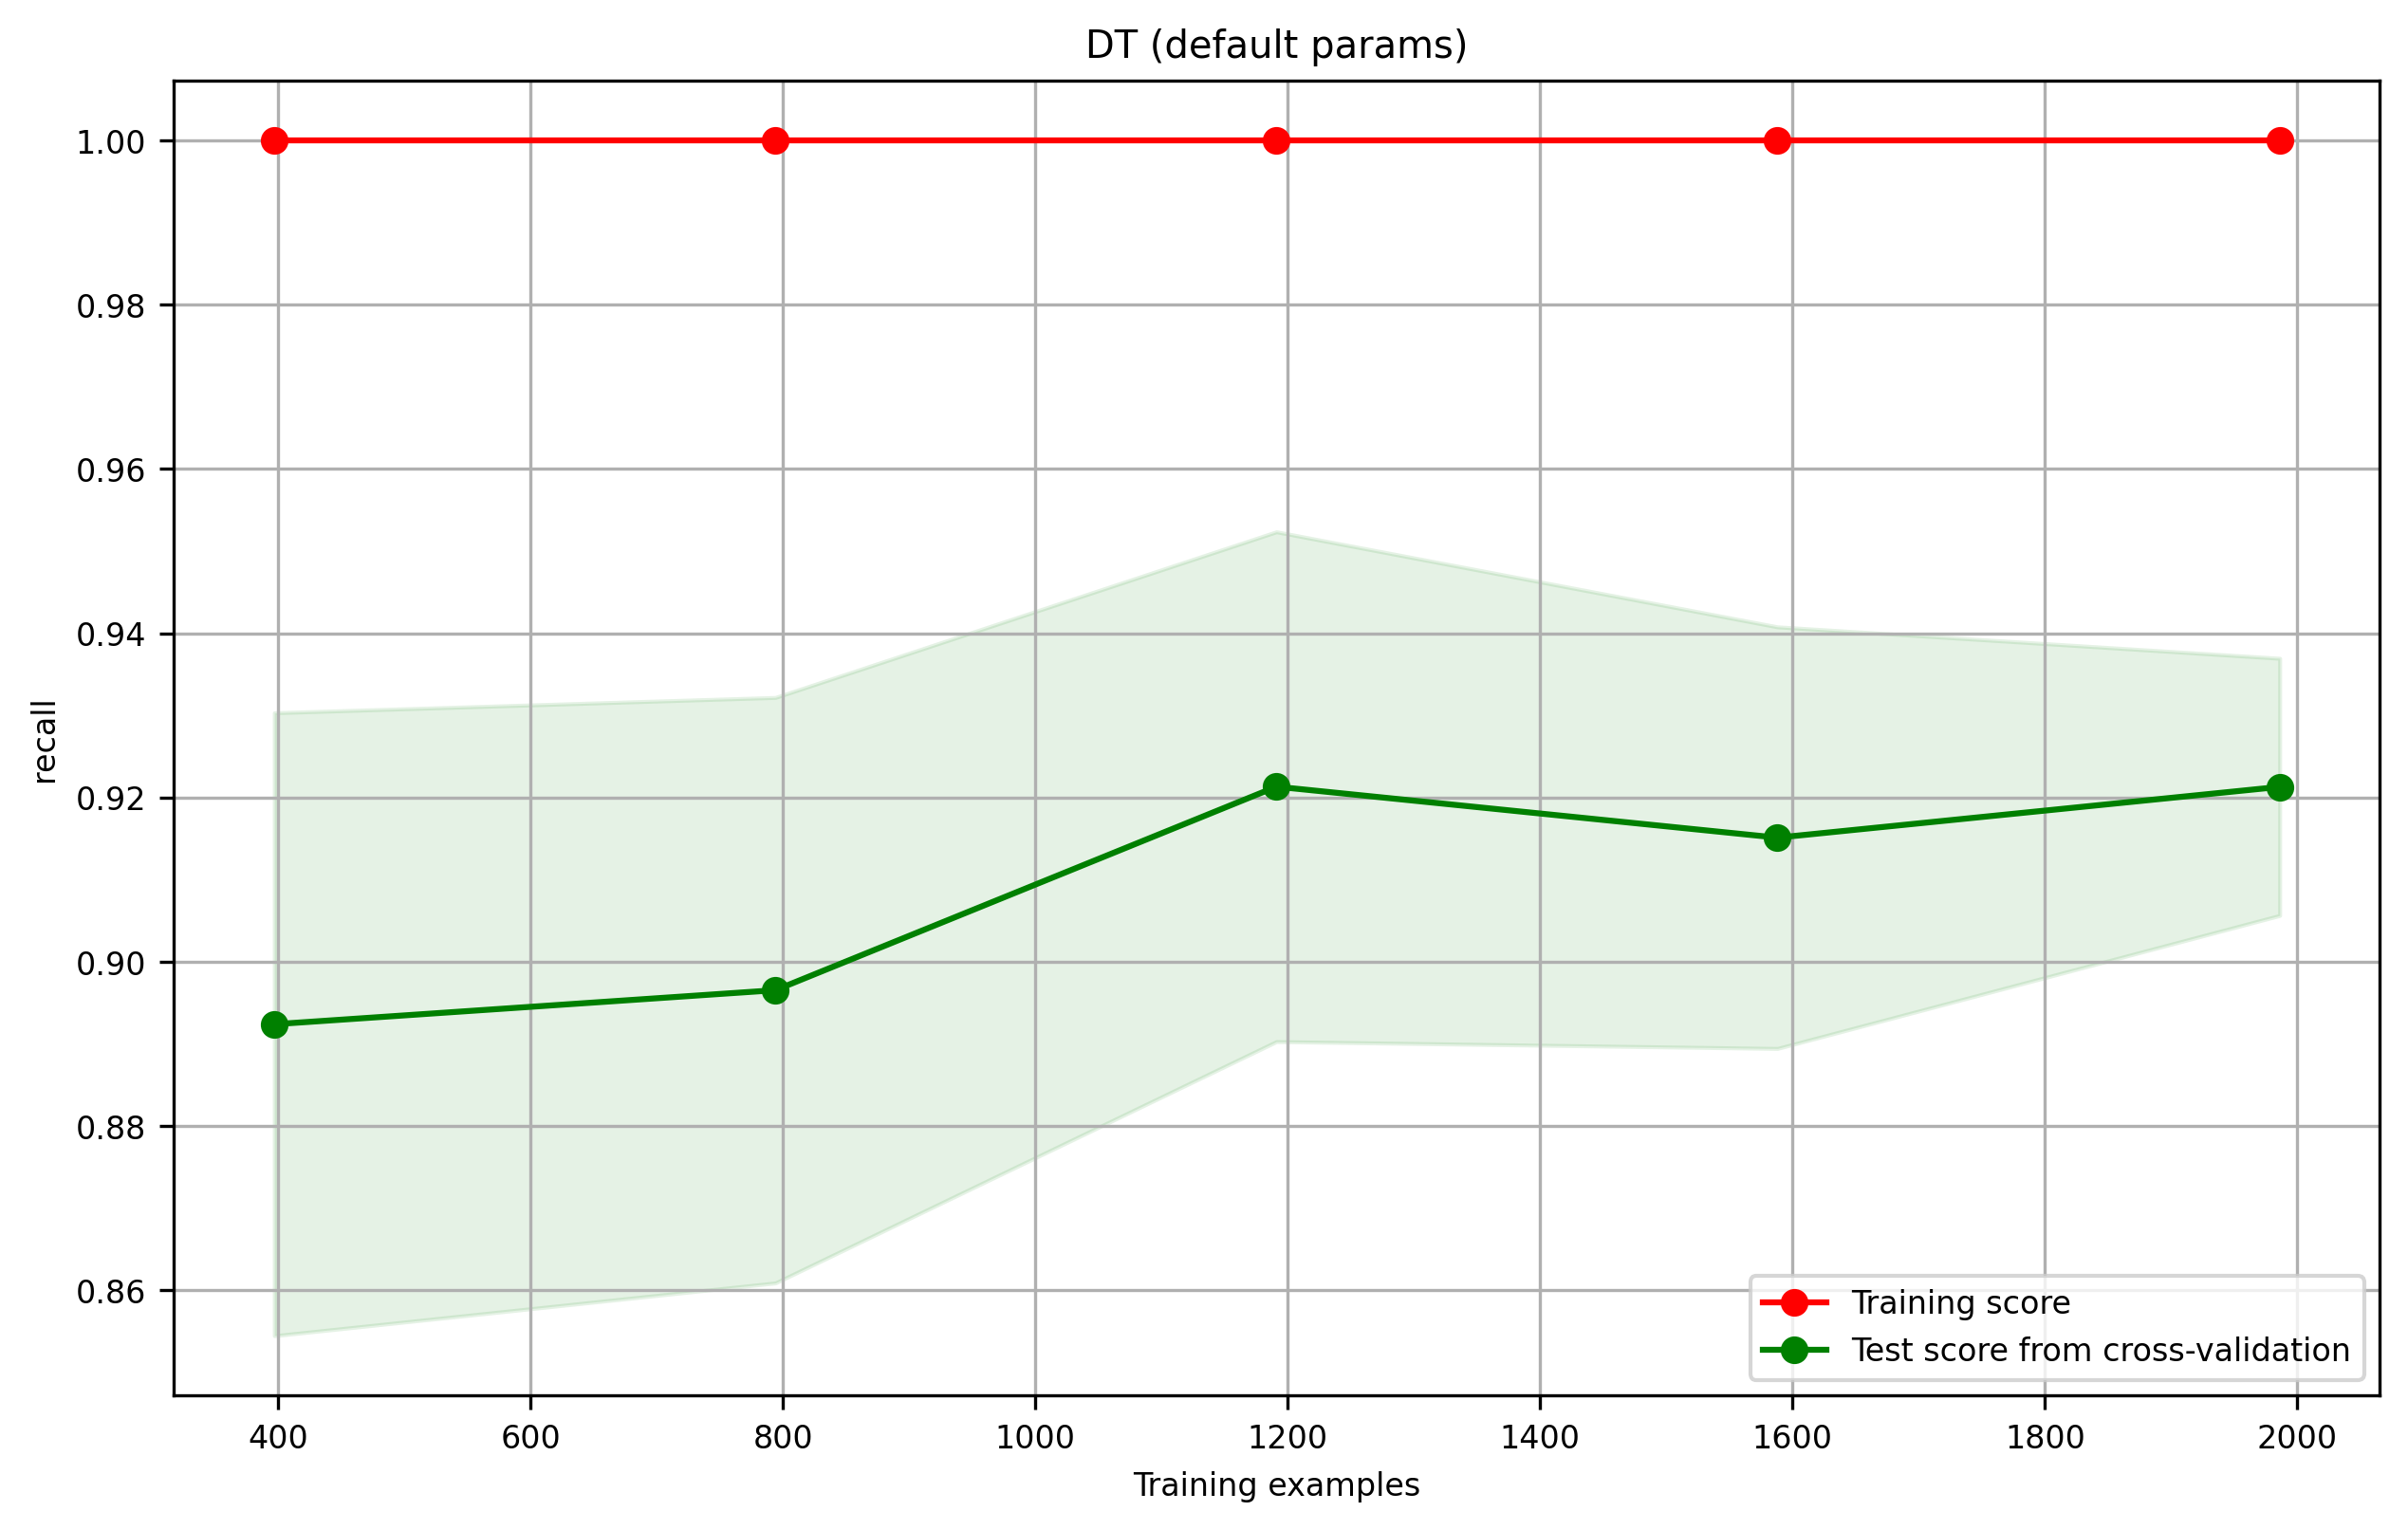

In [48]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

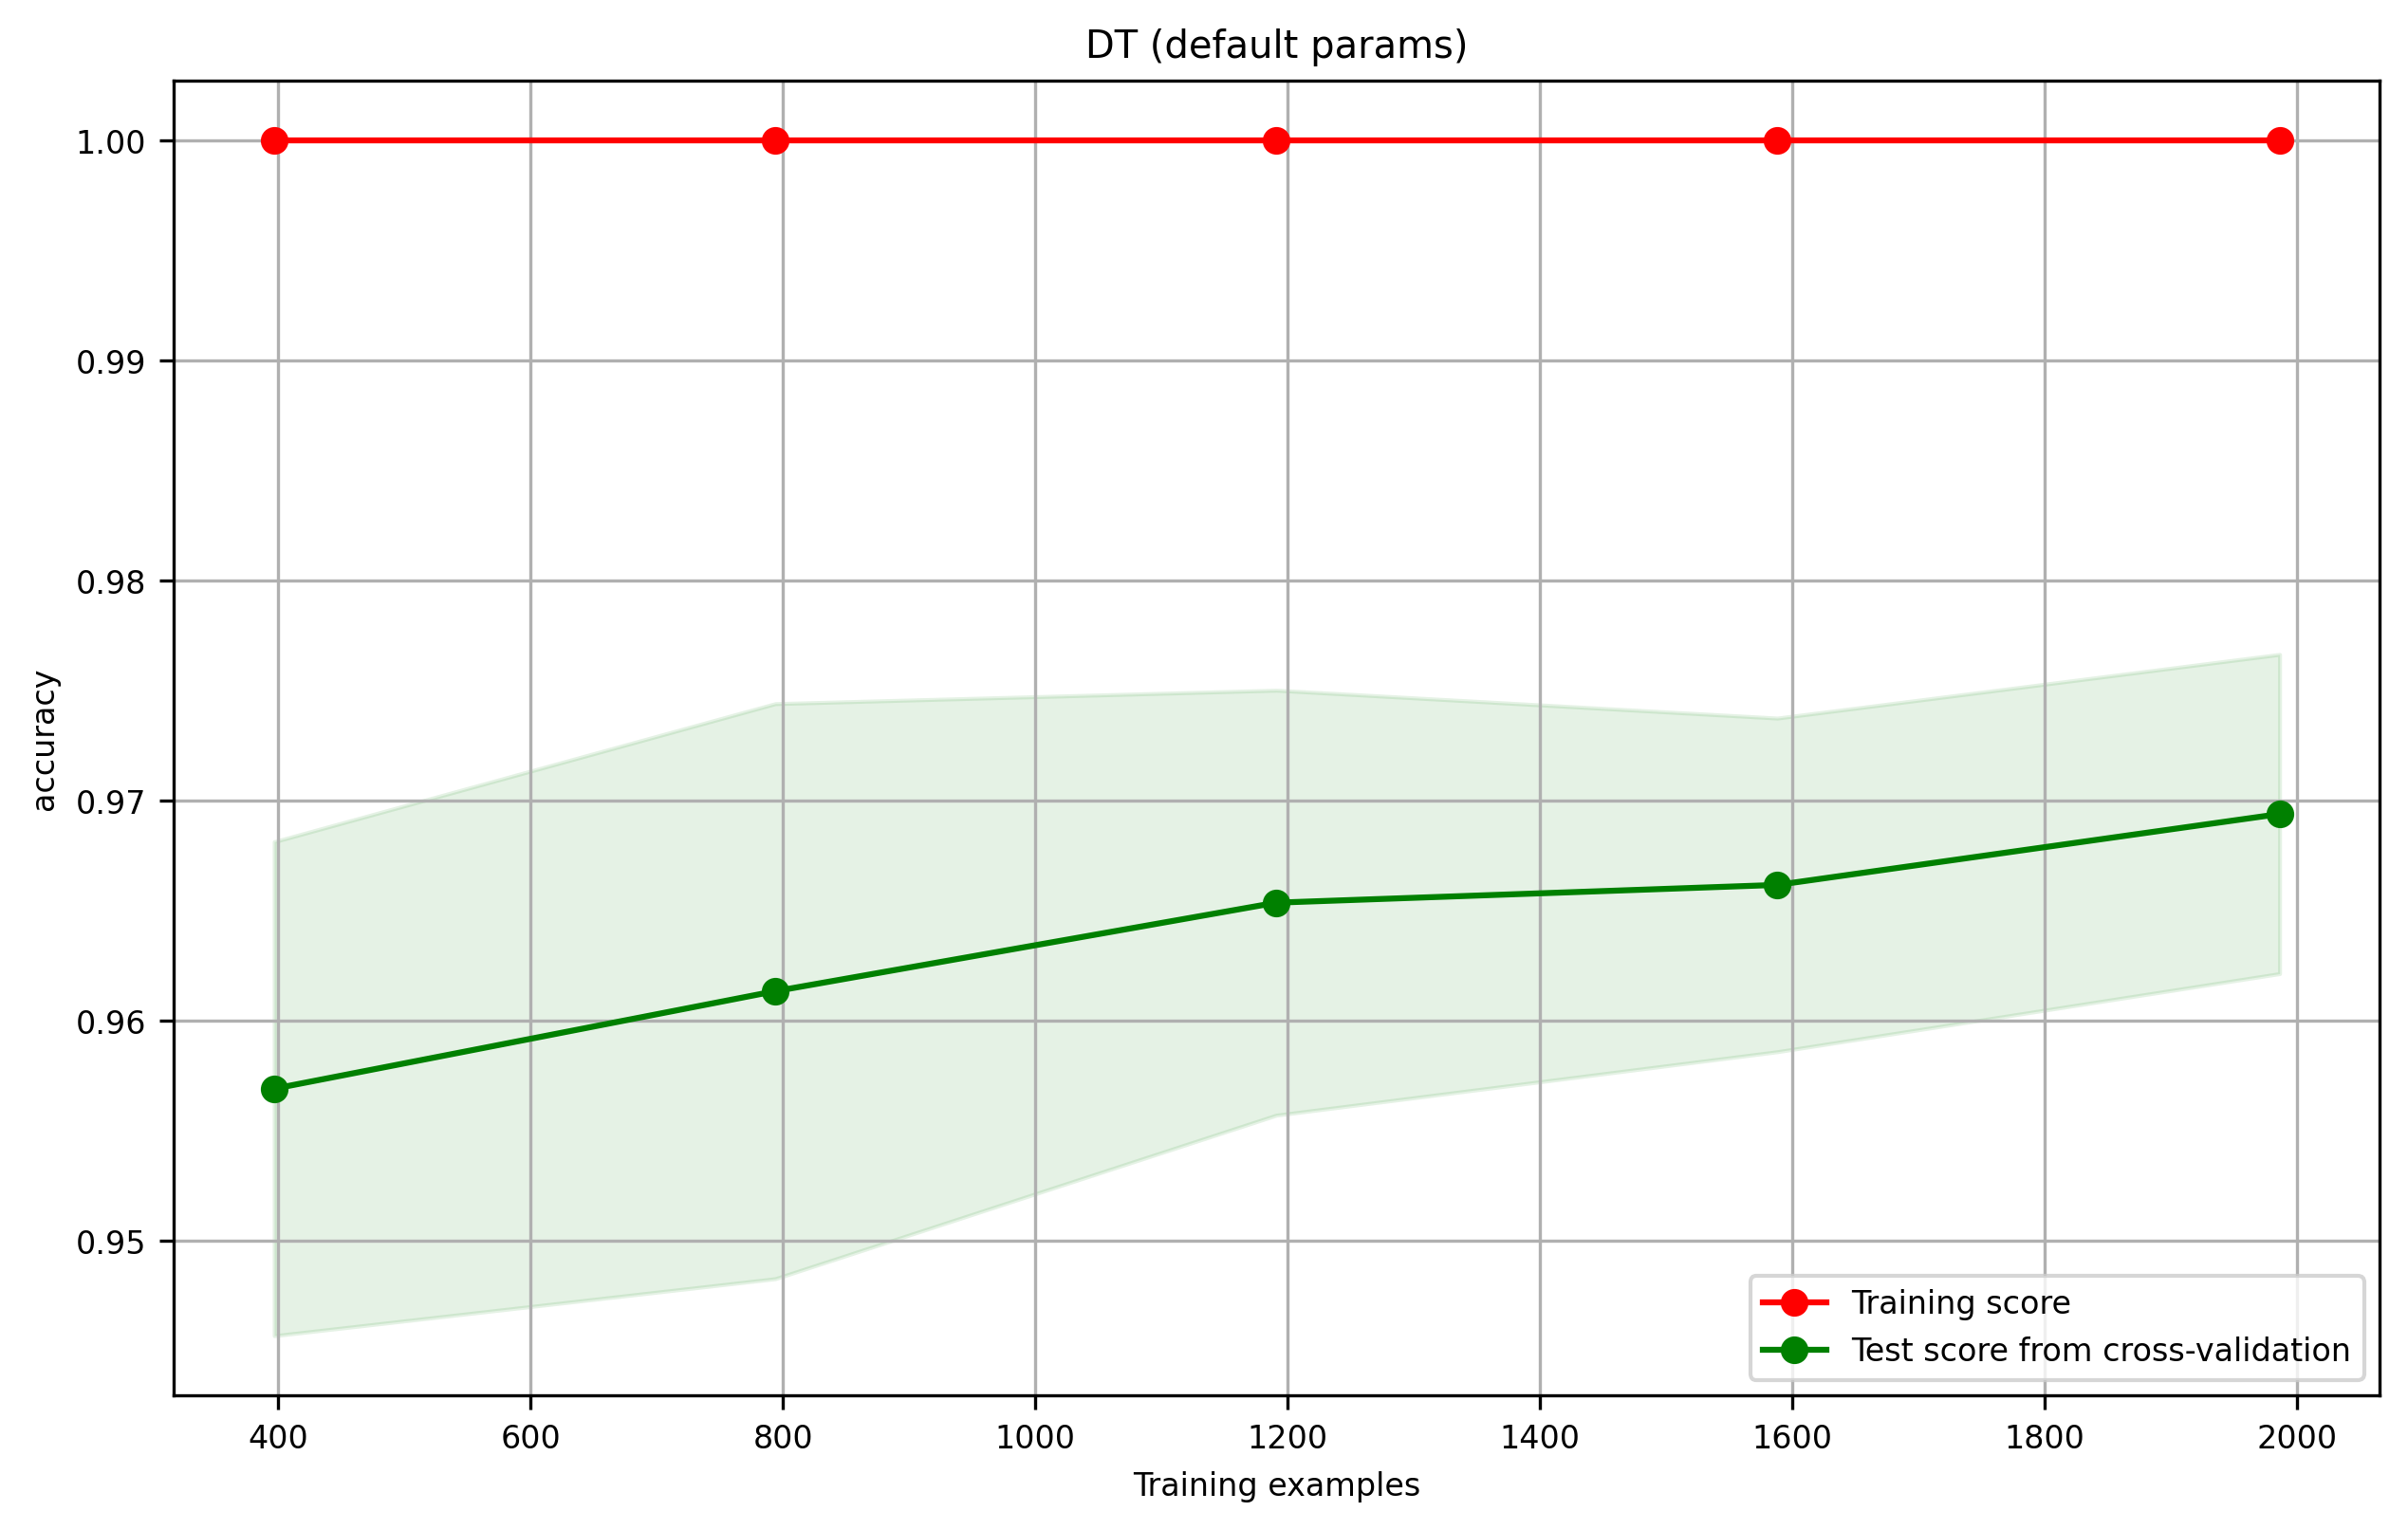

In [49]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?
2. ¿El rendimiento de validación mejora al agregar más ejemplos?
3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.
4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.

1. Se puede ver una brecha en ambas métricas. El training score se mantiene constantemente en 1.00 mientras que el test score no lo es. Esto dice que el modelo esta obteniendo una clasificacion perfecta en sus datos, pero en datos nuevos no lo logre igual, lo que indica que hay un overfitting y el modelo se aprende de memoria el set de entrenamiento.

2. Si, al aumentar los ejemplos, la precision aumenta en ambos casos y ademas se observa que la banda de incertibumbre se achica a medida que aumentan los ejemplos. El modelo se va haciendo mas estable.

3.  Aqui hay una alta varianza ya que el modelo si tiene la capacidad de ajustar los datos, por lo que no es demasiado simple o le falta complejidad. Al contrario, su capacidad se transforma en memorización del set.

4. El árbol de decisión base sobreajusta claramente al set de entrenamiento limitando su capacidad de generalizar a datos nuevos. Agregar más datos ayuda un poco a mejorar y estabilizar el rendimiento en validación, pero no resuelve el problema del todo ya que la brecha entre el entrenamiento y la validación se mantiene ancha en todo el rango.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [50]:
model_tree_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree_simple.fit(X_train, y_train)
y_pred_simple = model_tree_simple.predict(X_test)

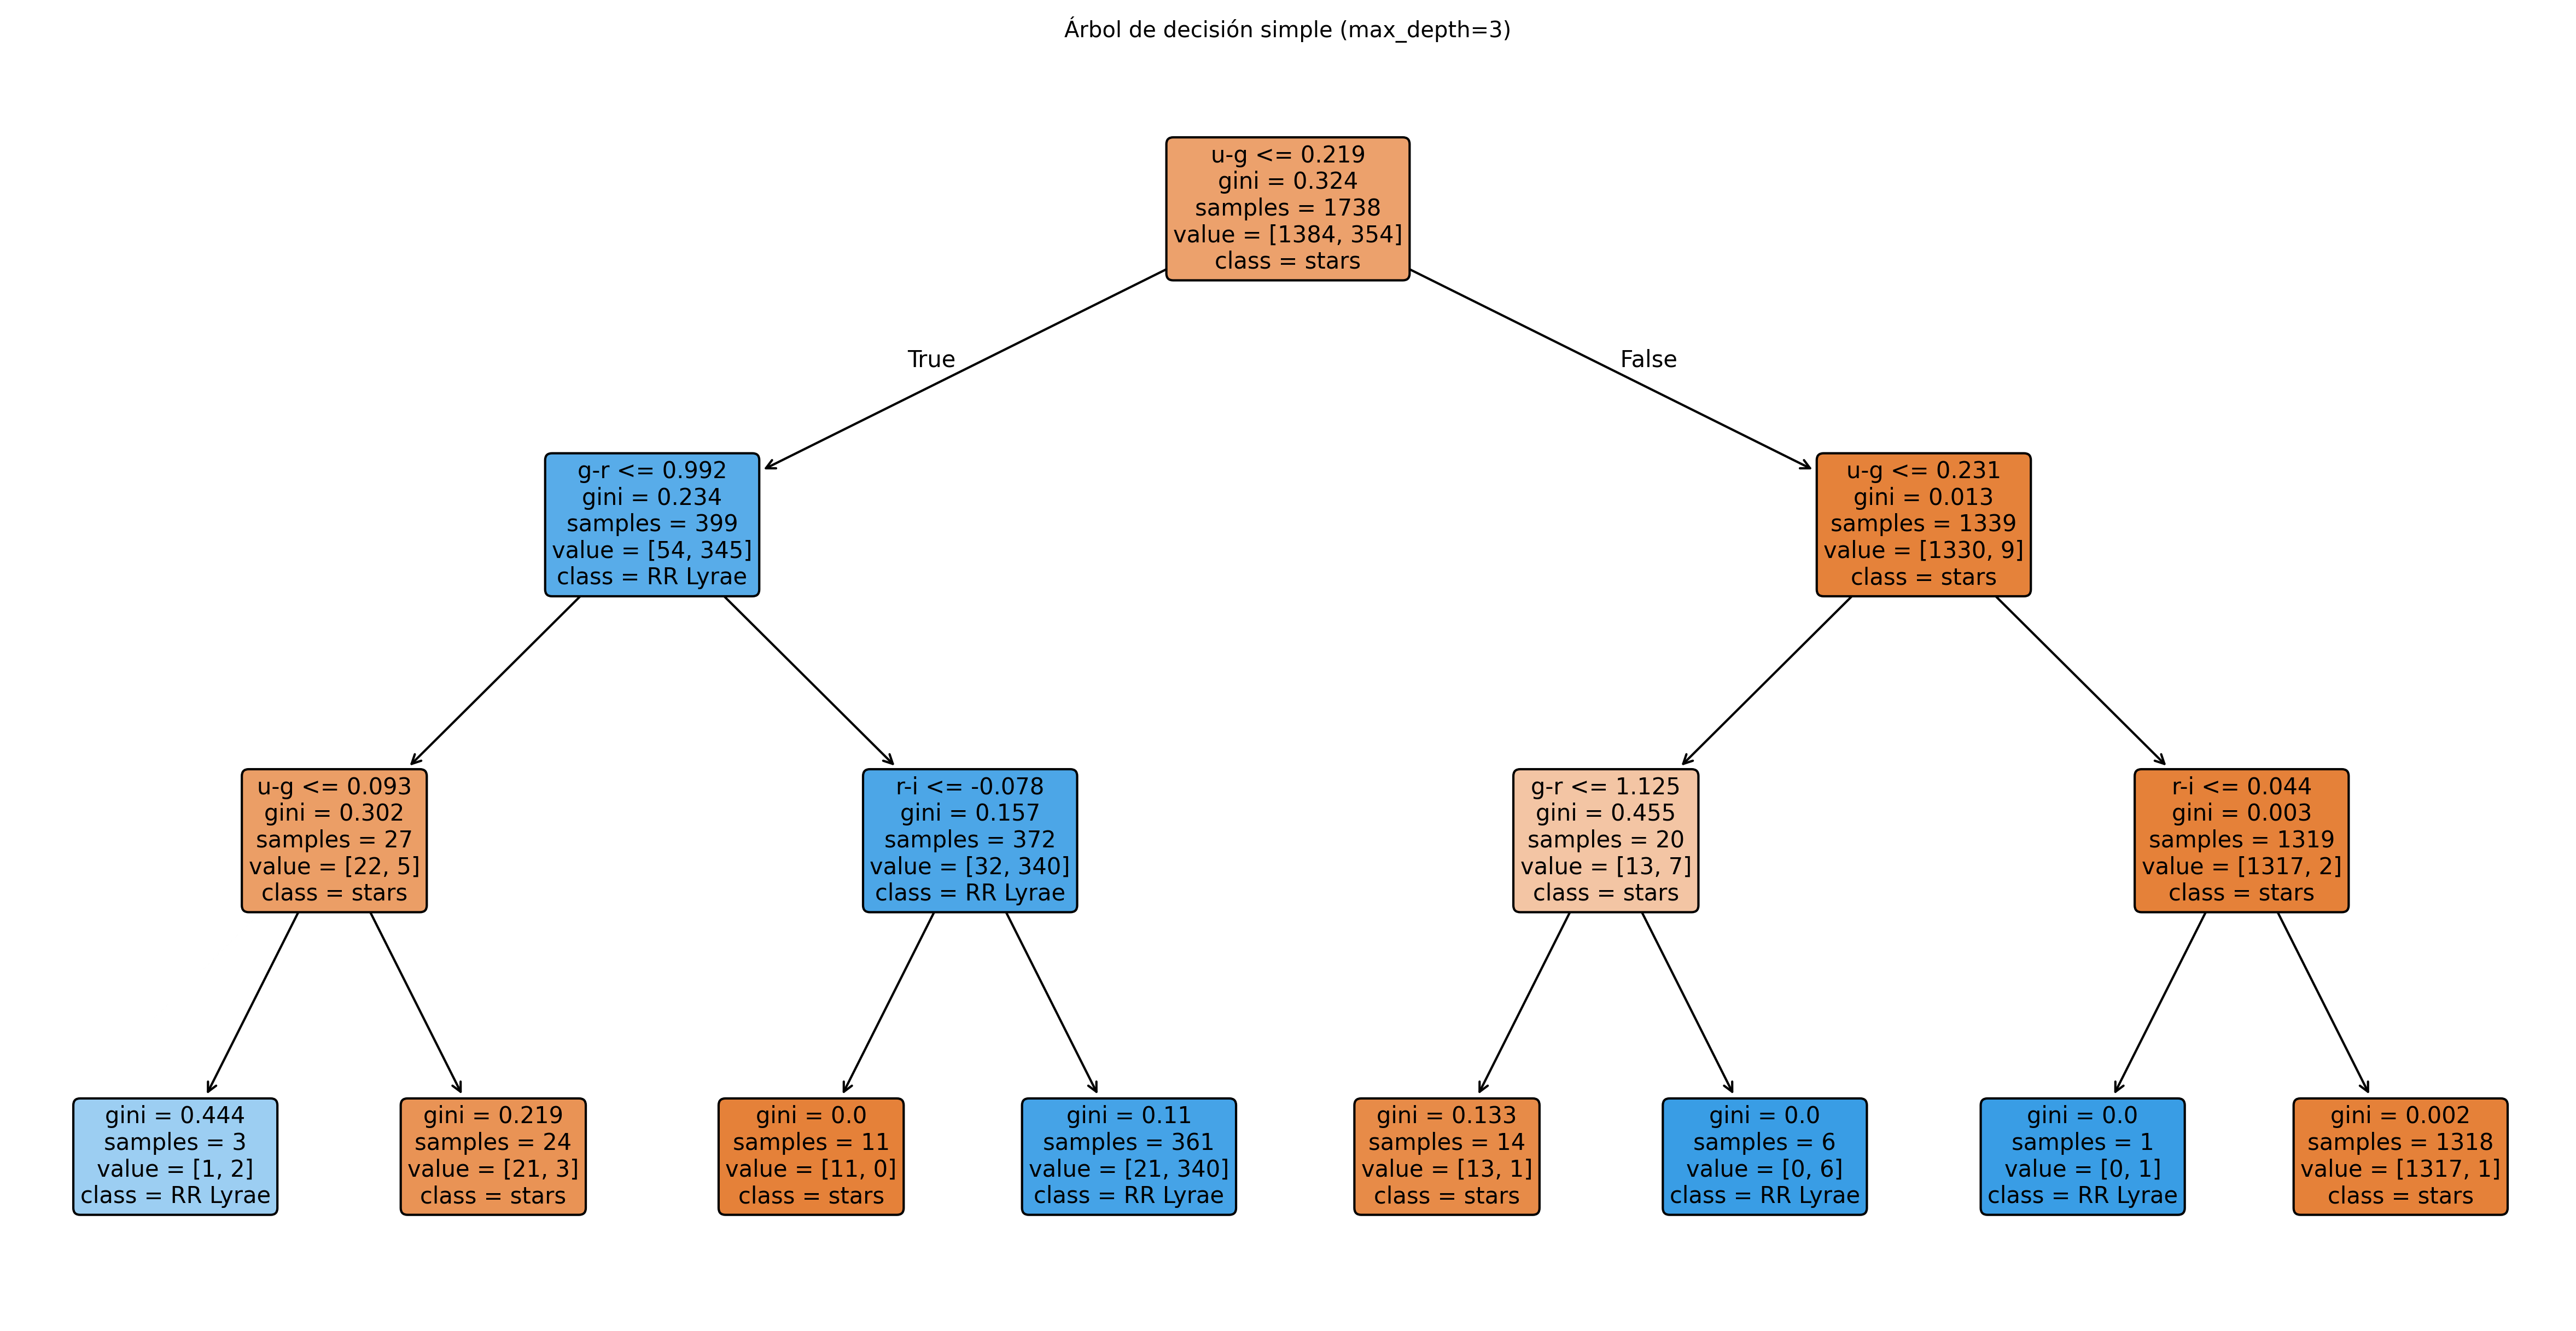

In [51]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree_simple,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión simple (max_depth=3)")
plt.show()

In [52]:
print("Accuracy :", metrics.accuracy_score(y_test, y_pred_simple))
print("Precision:", metrics.precision_score(y_test, y_pred_simple))
print("Recall   :", metrics.recall_score(y_test, y_pred_simple))
print("F1-score :", metrics.f1_score(y_test, y_pred_simple))

Accuracy : 0.9731543624161074
Precision: 0.9037037037037037
Recall   : 0.9457364341085271
F1-score : 0.9242424242424242


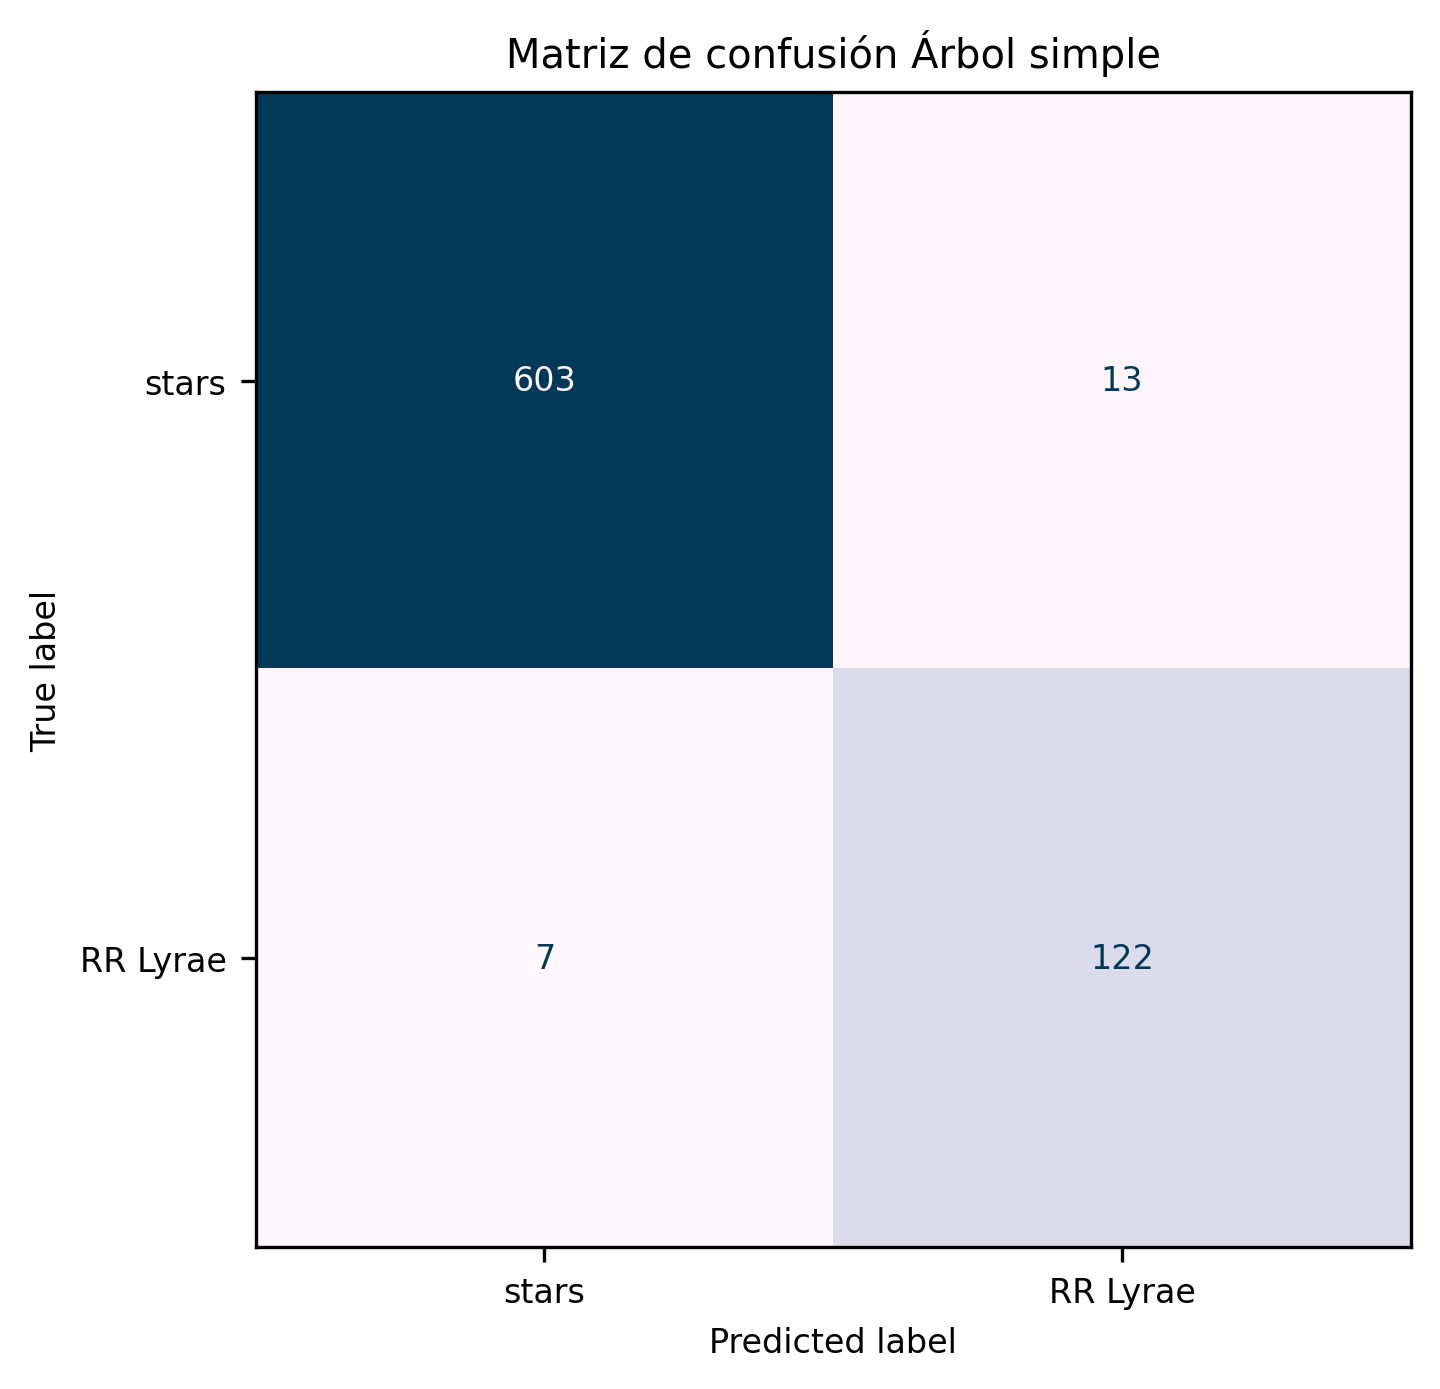

In [53]:
cm_simple = confusion_matrix(y_test, y_pred_simple)

fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_simple, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol simple")
plt.show()

In [54]:
model_base = DecisionTreeClassifier(random_state=5)
model_simple = DecisionTreeClassifier(max_depth=3, random_state=5)

for nombre, modelo in [("Base", model_base), ("Simple", model_simple)]:
    scores = cross_validate(
        modelo, X, y, cv=cv3,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_train_score=True
    )
    print(f"--- {nombre} ---")
    print("Train accuracy :", scores['train_accuracy'].mean())
    print("Test accuracy  :", scores['test_accuracy'].mean())
    print("Test precision :", scores['test_precision'].mean())
    print("Test recall    :", scores['test_recall'].mean())
    print("Test f1        :", scores['test_f1'].mean())
    print()

--- Base ---
Train accuracy : 1.0
Test accuracy  : 0.9693913480885312
Test precision : 0.9220460491889064
Test recall    : 0.9212843642611684
Test f1        : 0.921459222574953

--- Simple ---
Train accuracy : 0.981474042504882
Test accuracy  : 0.9770429025767509
Test precision : 0.9246994492397347
Test recall    : 0.9606314432989691
Test f1        : 0.9421256472761185



<module 'matplotlib.pyplot' from '/Users/bastianparedes/ML/lib/python3.9/site-packages/matplotlib/pyplot.py'>

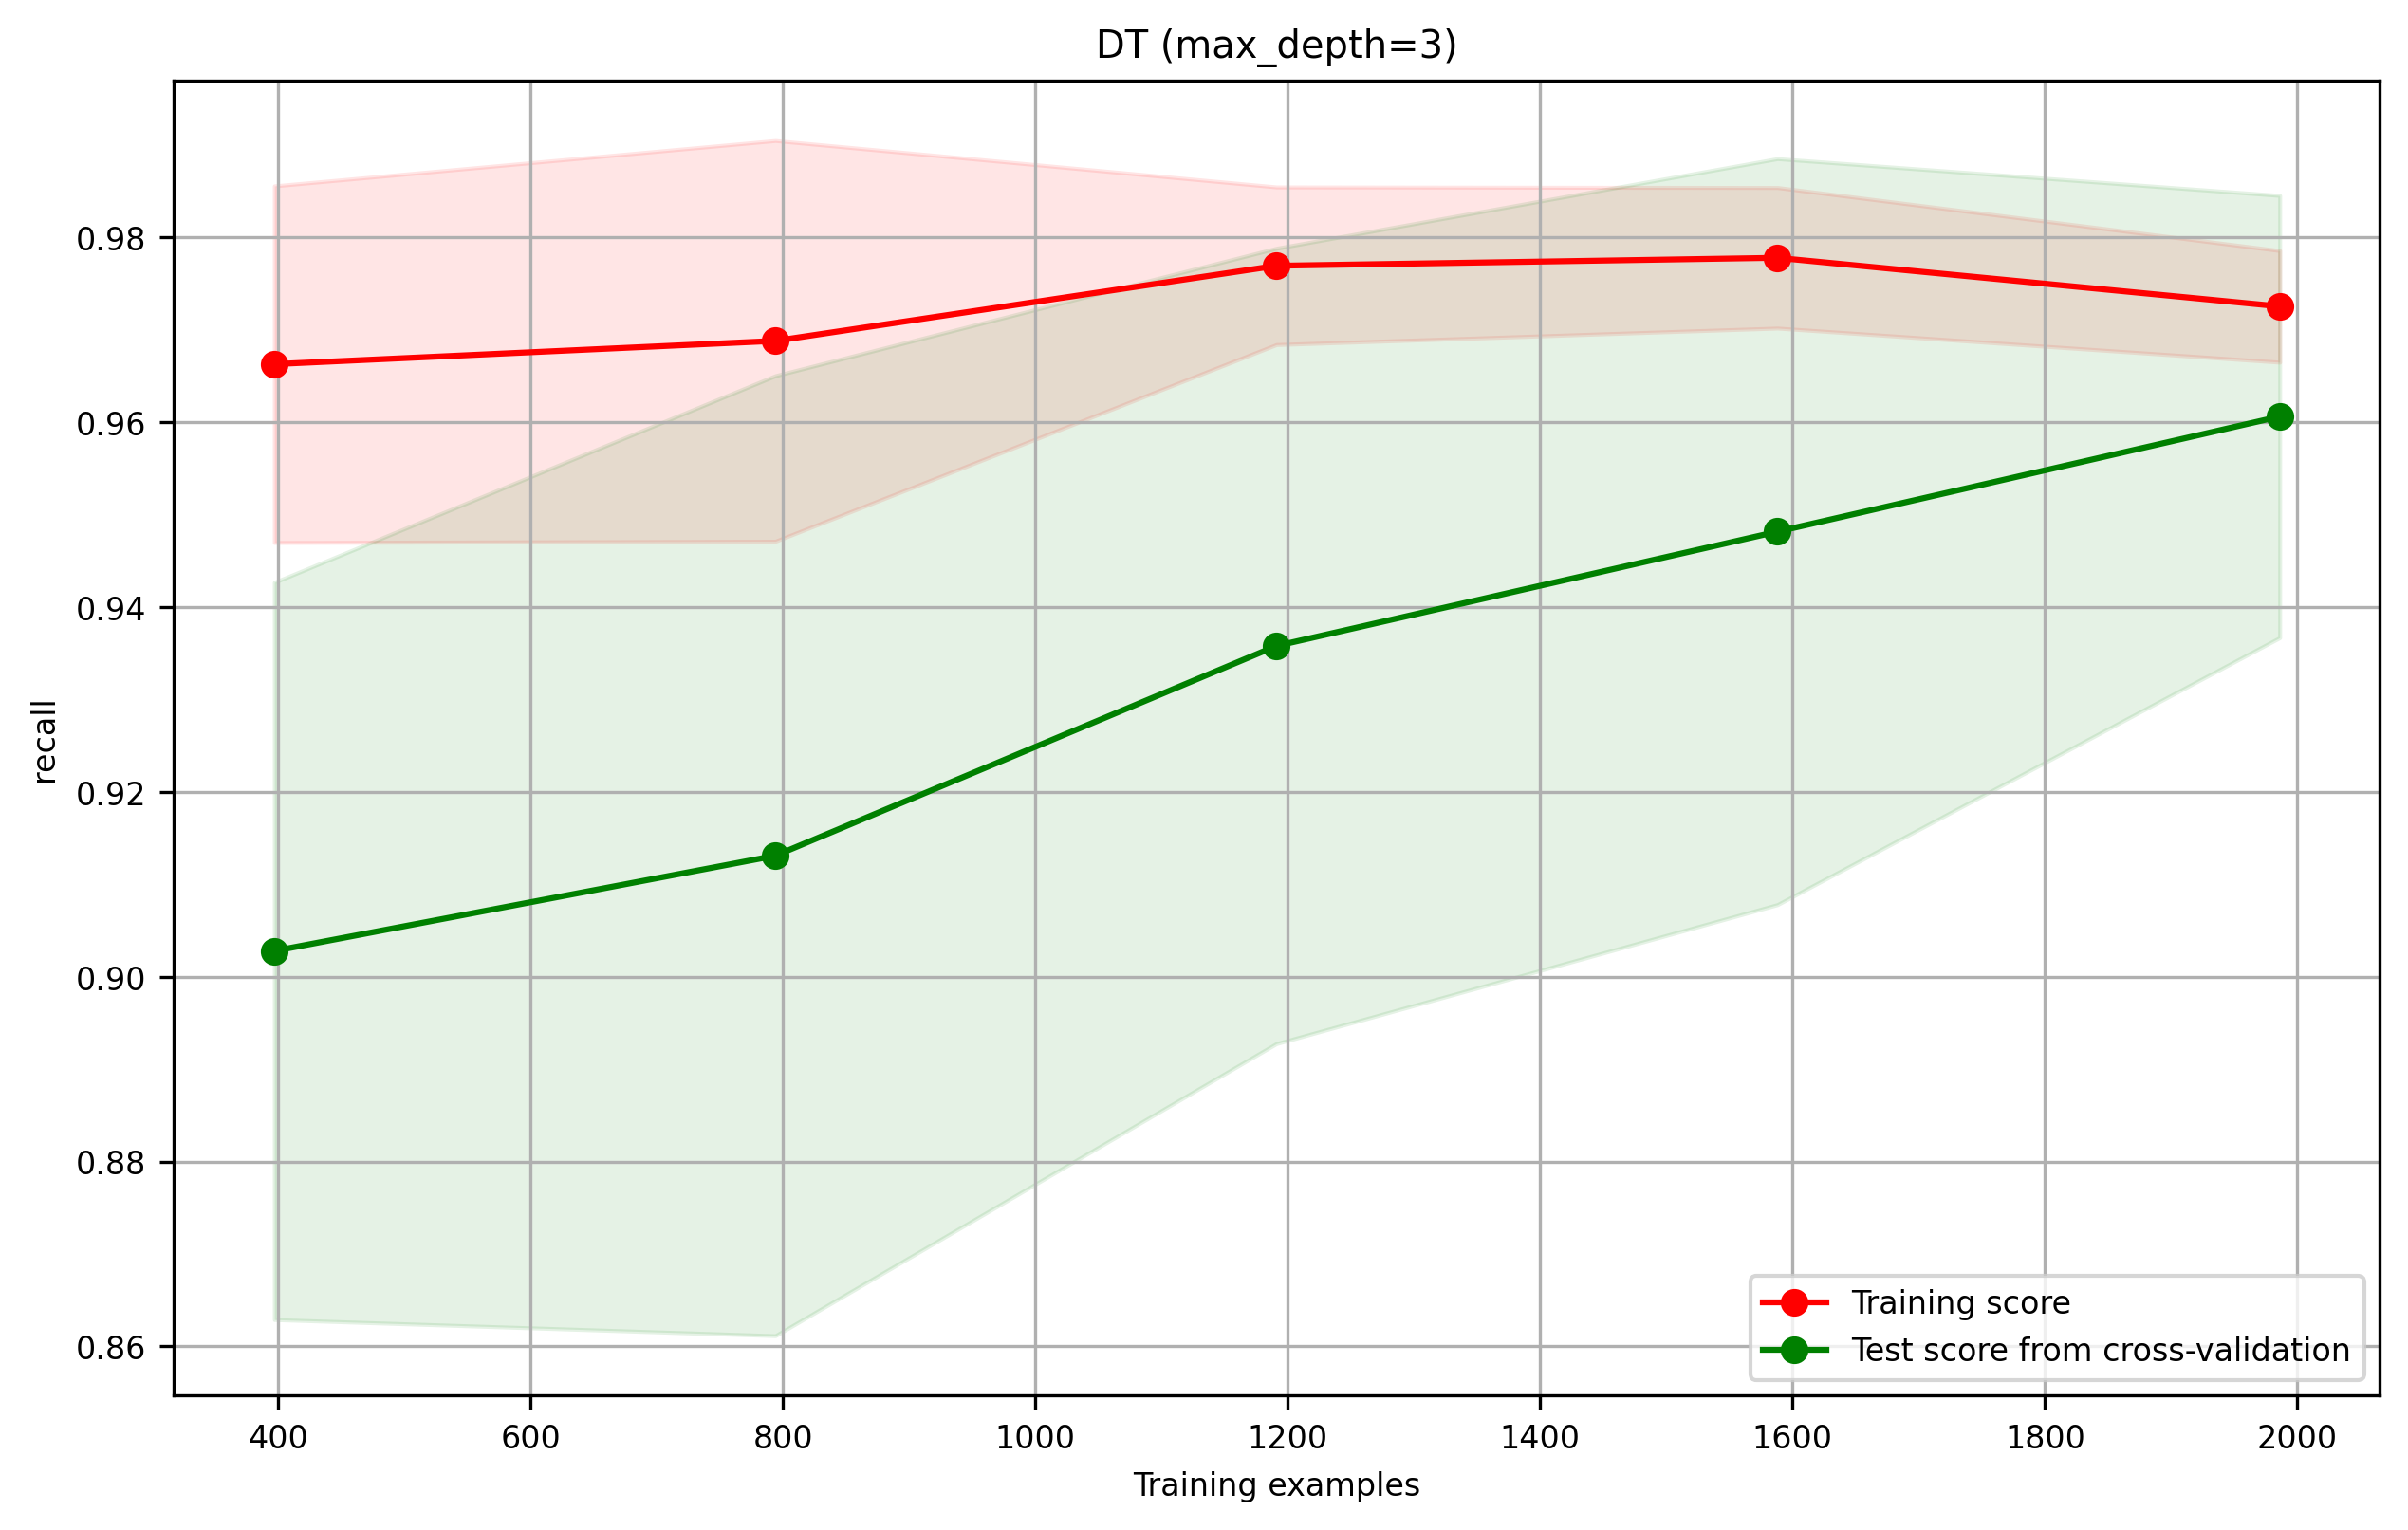

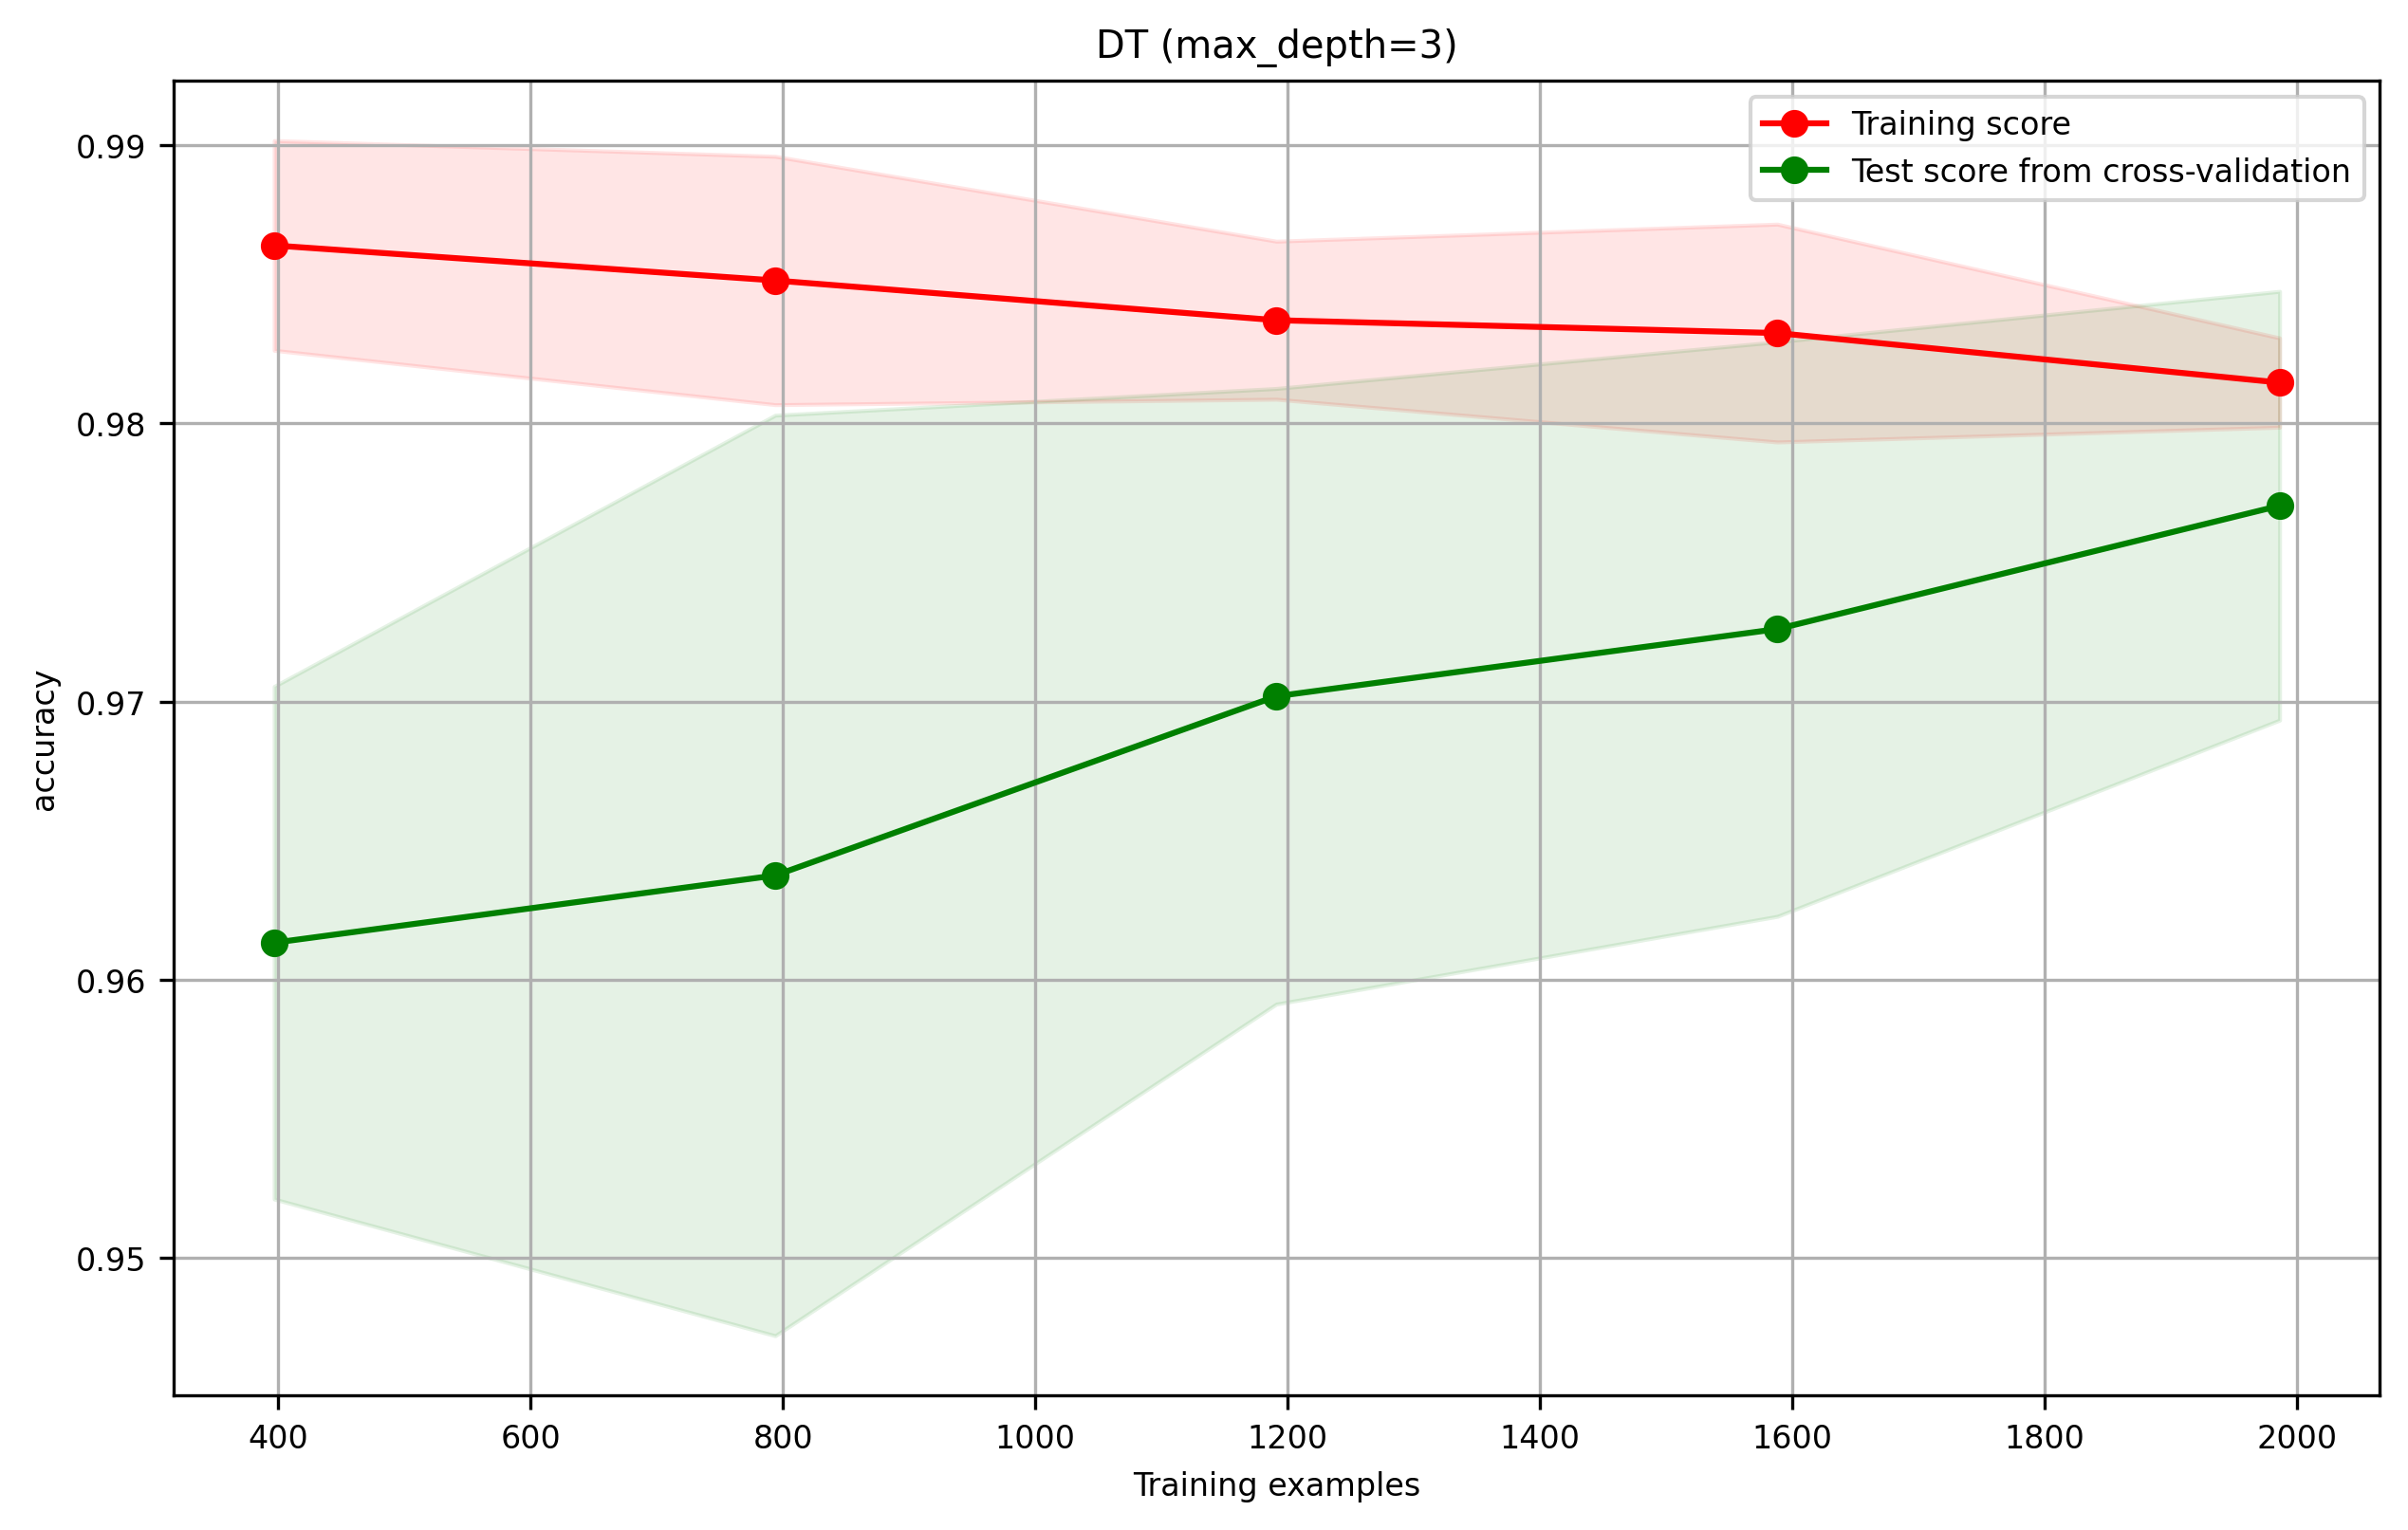

In [55]:
plot_learning_curve(model_simple, 'DT (max_depth=3)', X, y, cv=cv3, scoring='recall')
plot_learning_curve(model_simple, 'DT (max_depth=3)', X, y, cv=cv3, scoring='accuracy')

### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?
2. ¿El árbol más simple empeoró o mejoró la generalización?
3. ¿Qué sugieren estos resultados sobre el árbol base?
4. En este problema, ¿parece conveniente usar el árbol sin restricciones?
5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?

1. Se puede ver que el train accuracy y el recall del train score bajaron de 1.0 en el árbol mas simple, lo que indica que ya no memoriza. Pero se puede ver que tanto el recall como el accuracy del test score suben a de 0.90 a 0.96 y de 0.96 a 0.98 respectivamente. Lo que indica que al sacrificar un ajuste perfecto en el entrenamiento se logro mejorar la calidad y el desempeño del modelo.

2. El árbol mas simple mejor la generalización ya que logra usar el modelo en toda la muestra y no solo en el set de entrenamiento. Al dejar la profundidad máxima como 3 el arbol no pudo aprenderse de memoria el set de entrenamiento.

3. Esto confirma que el arbol base estaba sobreajustado y que efectivamente se aprendio el set de memoria. Esto lo hizo incapaz de generalizar el modelo para mas datos de manera correcta. 

4. No, si se usa el árbol sin restricciones estamos dejandole libertad al modelo para que busque la el mejor ajuste de entrenamiento y sobreajustar los demas datos. Adememas el árbol restringido tuvo mejor accuracy, recall y F1.

5. La métrica mas importante aqui es recall ya que esta nos ayuda a ver la cantidad de casos de reales positivos se encontraron correctamente. Como buscamos RR Lyrae dentro de una muestra de estrellas, esta métrica nos ayuda a confirmar si es que se clasificaron bien.

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?
2. ¿Qué ocurre cuando `k` es muy pequeño?
3. ¿Qué ocurre cuando `k` es muy grande?
4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?
5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

scores_knn = cross_validate(
    knn_pipeline, X, y, cv=cv3,
    scoring=['accuracy', 'precision', 'recall', 'f1'],
    return_train_score=True
)

In [58]:
print("Train accuracy :", scores_knn['train_accuracy'].mean())
print("Test accuracy  :", scores_knn['test_accuracy'].mean())
print("Test precision :", scores_knn['test_precision'].mean())
print("Test recall    :", scores_knn['test_recall'].mean())
print("Test f1        :", scores_knn['test_f1'].mean())

Train accuracy : 0.9819775164956914
Test accuracy  : 0.977847731550594
Test precision : 0.9215128205128206
Test recall    : 0.9689432989690723
Test f1        : 0.9445687163675001


In [60]:
model_simple = DecisionTreeClassifier(max_depth=3, random_state=5)

modelos = [
    ("Simple (árbol)", model_simple),
    ("kNN (k=5)", knn_pipeline)
]

for nombre, modelo in modelos:
    scores = cross_validate(
        modelo, X, y, cv=cv3,
        scoring=['accuracy', 'precision', 'recall', 'f1'],
        return_train_score=True
    )
    print(f"--- {nombre} ---")
    print("Train accuracy :", scores['train_accuracy'].mean())
    print("Test accuracy  :", scores['test_accuracy'].mean())
    print("Test precision :", scores['test_precision'].mean())
    print("Test recall    :", scores['test_recall'].mean())
    print("Test f1        :", scores['test_f1'].mean())
    print()

--- Simple (árbol) ---
Train accuracy : 0.981474042504882
Test accuracy  : 0.9770429025767509
Test precision : 0.9246994492397347
Test recall    : 0.9606314432989691
Test f1        : 0.9421256472761185

--- kNN (k=5) ---
Train accuracy : 0.9819775164956914
Test accuracy  : 0.977847731550594
Test precision : 0.9215128205128206
Test recall    : 0.9689432989690723
Test f1        : 0.9445687163675001



In [61]:
valores_k = [1, 3, 5, 7, 9, 11, 15, 21, 31]

resultados_k = {'k': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}

for k in valores_k:
    pipeline_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    scores_k = cross_validate(
        pipeline_k, X, y, cv=cv3,
        scoring=['accuracy', 'precision', 'recall', 'f1']
    )
    resultados_k['k'].append(k)
    resultados_k['accuracy'].append(scores_k['test_accuracy'].mean())
    resultados_k['precision'].append(scores_k['test_precision'].mean())
    resultados_k['recall'].append(scores_k['test_recall'].mean())
    resultados_k['f1'].append(scores_k['test_f1'].mean())

df_k = pd.DataFrame(resultados_k)
df_k

,k,accuracy,precision,recall,f1
0,1,0.968183,0.914128,0.923411,0.918686
1,3,0.976640,0.923070,0.960653,0.941376
2,5,0.977848,0.921513,0.968943,0.944569
3,7,0.978250,0.918473,0.975129,0.945853
4,9,0.977042,0.911946,0.977212,0.943177
5,11,0.976637,0.907450,0.981357,0.942602
6,15,0.973818,0.899939,0.975129,0.935671
7,21,0.972611,0.896106,0.973067,0.932763
8,31,0.971804,0.894309,0.970984,0.930786


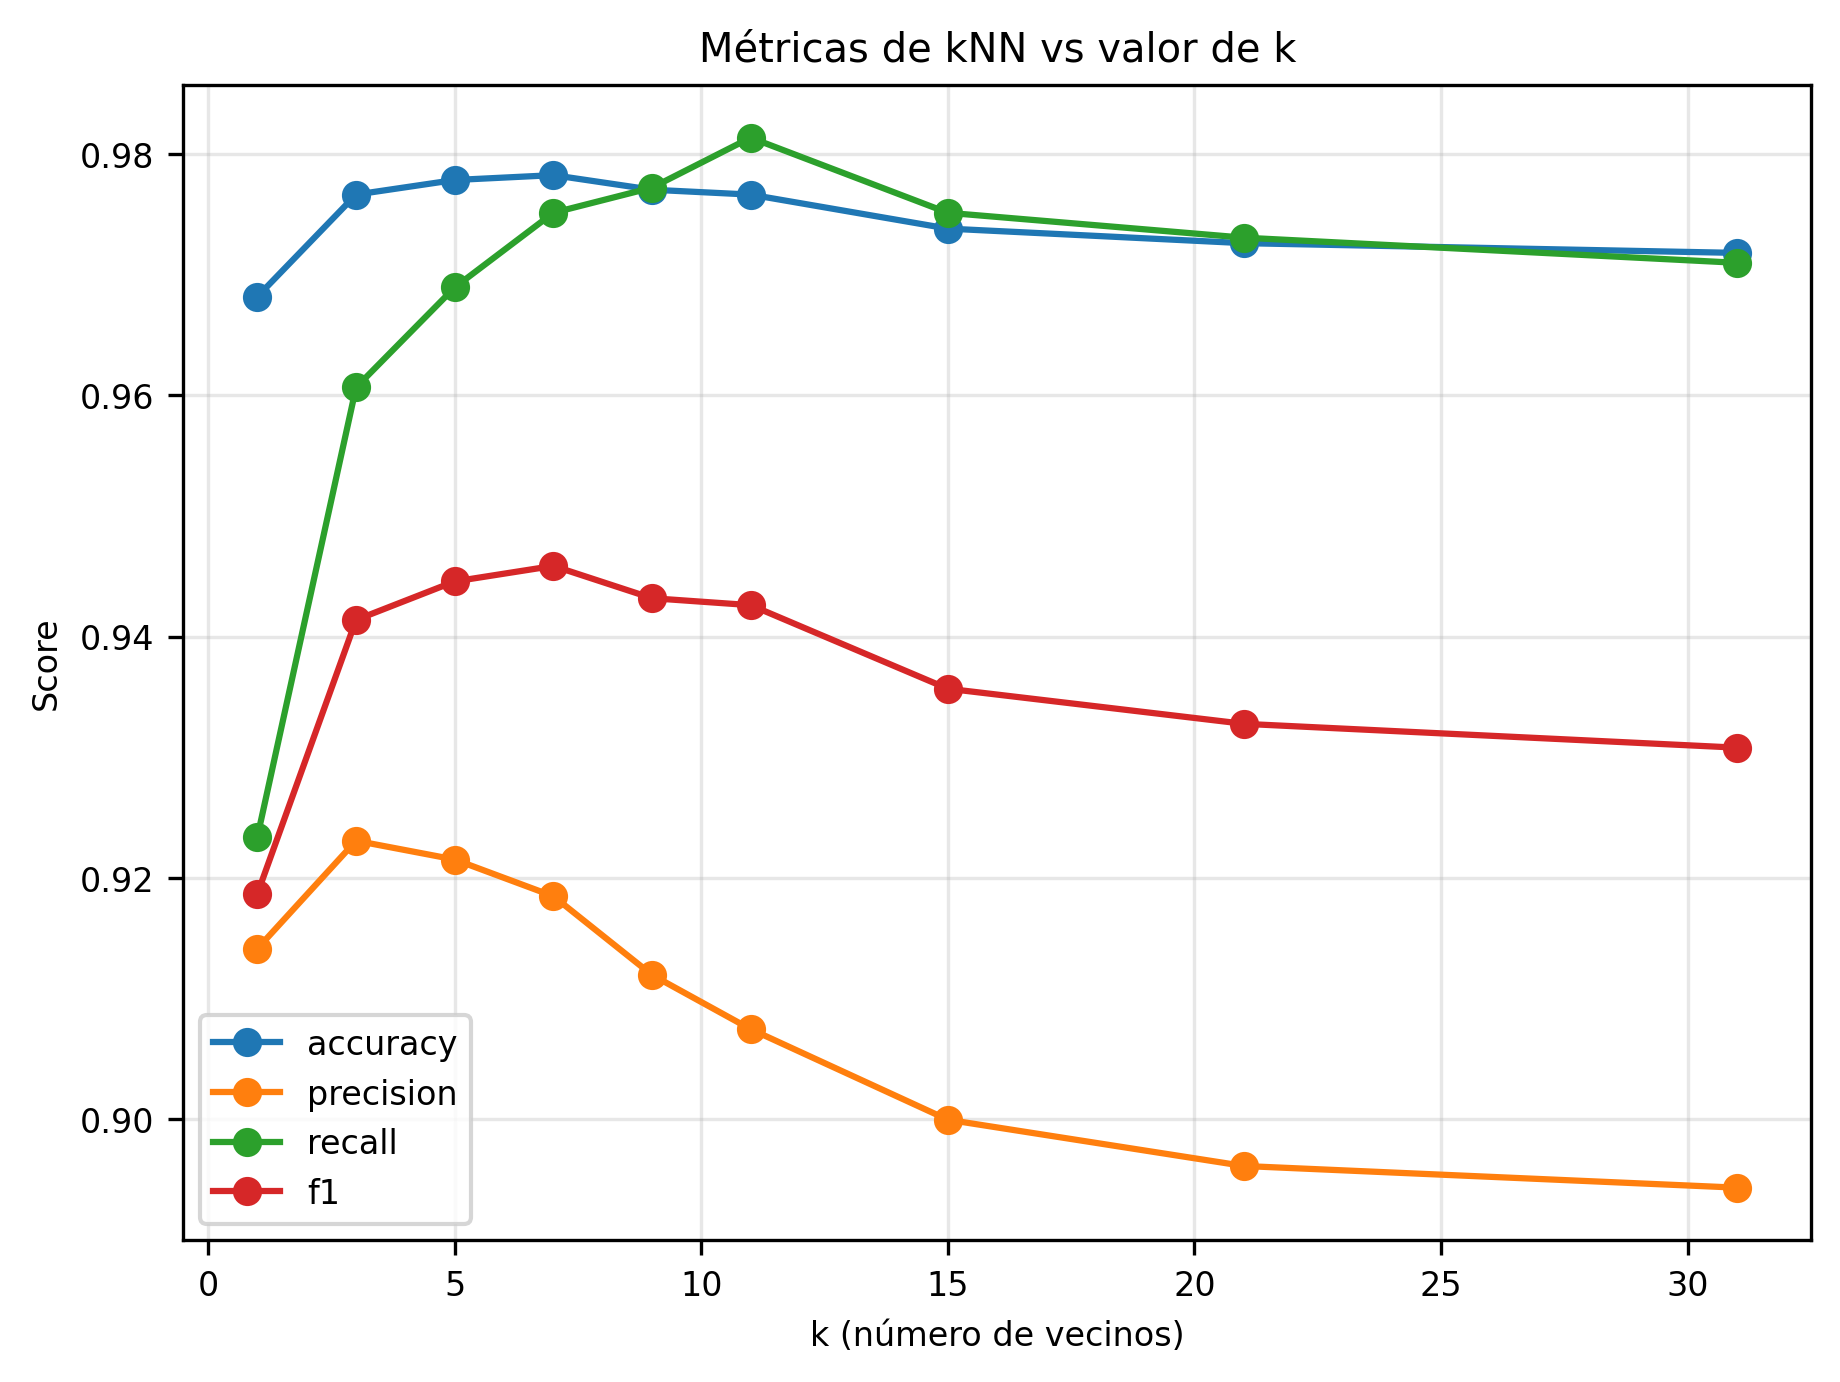

In [62]:
plt.figure(figsize=(7,5))

for metrica in ['accuracy', 'precision', 'recall', 'f1']:
    plt.plot(df_k['k'], df_k[metrica], marker='o', label=metrica)

plt.xlabel('k (número de vecinos)')
plt.ylabel('Score')
plt.title('Métricas de kNN vs valor de k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. Se puede ver que el modelo kNN le gana al arbol simple en todas las métricas (menos precisión). Por lo que este modelo supera al árbol en accuracy.

2. Cuando k es muy pequeño, se pueden ver valores mas pequeños en todas las métricas. Hay m ayor varianza por lo que el modelo puede memorizar puntos individuales.

3. Cuando k es muy grande, se puede ver que el score de las métricas de F1 y precisión comienzan a bajar mucho. Esto porque al tener muchos vecinos el modelo pierde la capacidad de distinguir bien y hay un subajuste.

4. El valor de k que parece dar el mejor equilibrio es el k = 7 ya que se puede ver que ahi esta en su maximo el score de F1. Este nos habla del equilibiro del modelo y del entrenamiento. Además el resto de las metricas también tienen un buen score en esos puntos, y aunque no sean máximos, estan birn balanceados. 

5. Al no ser rectangular, la separación entre clases de kNN podria ser ventajosa ya que se puede adaptar a fronteras de cualquier forma. En este caso es una ventaja ya que la separacion en RR Lyrae y no RR Lyrae en el espacio de colores no sigue una forma rectangular y el arbol necesitaria muchos mas cortes. En general, esta ventaja depende de la distribución real de los datos.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.